In [1]:
import sklearn
import numpy as np
import scipy as sp
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier


In [2]:
coffee_data = pd.read_csv(r"..\data\reduced_data_bin.csv")
coffee_data.describe()

,clim_68_pet_annual,clim_21_tmax9_sep,clim_55_prec_coldest_q,clim_49_prec_wettest_m,clim_48_Annual_prec,clim_60_pet5_may,clim_43_tannual_range,clim_34_prec10_oct,clim_35_prec11_nov,clim_39_isotherm,...,env_78_wat_22,env_78_wat_17,env_78_wat_1.1,env_78_wat_18,env_78_wat_15,env_78_wat_19,env_78_wat_24,env_78_wat_0,caffeine_class,caffeine_percent
count,450.000000,450.000000,450.000000,450.000000,450.000000,450.000000,450.000000,450.000000,450.000000,450.000000,...,450.000000,450.000000,450.000000,450.000000,450.000000,450.000000,450.000000,450.000000,450.000000,450.000000
mean,1252.891111,273.322222,205.151111,335.953333,1759.608889,92.371111,155.424444,109.795556,218.137778,64.215556,...,0.004444,0.006667,0.006667,0.006667,0.004444,0.008889,0.002222,0.053333,0.208889,0.017122
std,206.998228,28.144800,187.080903,96.158764,739.018872,21.047990,33.531554,41.198395,51.918890,4.490051,...,0.066592,0.081468,0.081468,0.081468,0.066592,0.093965,0.047140,0.224947,0.406967,0.087017
min,764.000000,210.000000,5.000000,84.000000,352.000000,57.000000,100.000000,32.000000,55.000000,56.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1133.250000,254.000000,52.000000,306.000000,1209.000000,76.000000,131.000000,75.000000,183.000000,60.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,1226.500000,260.500000,126.000000,351.000000,1600.500000,89.000000,153.000000,108.000000,231.000000,65.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,1402.000000,298.000000,389.500000,397.000000,2357.250000,102.000000,170.000000,148.000000,254.000000,67.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,1829.000000,341.000000,611.000000,514.000000,3363.000000,148.000000,251.000000,178.000000,335.000000,74.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.700000


In [3]:

column_names = coffee_data.drop(columns=['caffeine_class', 'caffeine_percent']).columns

# Scale the features
#scaler = StandardScaler()
#X_scaled_std = scaler.fit_transform(coffee_data.drop(columns=['caffeine_class', 'caffeine_percent'])) 


# Define X and y
y = coffee_data['caffeine_class']
#X = X_scaled_std.copy()
X = coffee_data.drop(columns=['caffeine_class', 'caffeine_percent'])

# Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Train Random Forest model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Get feature importances
importances = model.feature_importances_

# Use the stored column names to map the importances back to the feature names
important_features = sorted(zip(column_names, importances), key=lambda x: x[1], reverse=True)
feature_importance_dict = {feature: importance for feature, importance in zip(column_names, importances)}

# Display the most important features
for feature, importance in important_features:
    print(f"Feature: {feature}, Importance: {importance:.4f}")


Feature: clim_34_prec10_oct, Importance: 0.0622
Feature: clim_40_temp_season, Importance: 0.0562
Feature: clim_35_prec11_nov, Importance: 0.0545
Feature: clim_49_prec_wettest_m, Importance: 0.0534
Feature: clim_69_cwd_annual, Importance: 0.0480
Feature: clim_55_prec_coldest_q, Importance: 0.0468
Feature: clim_21_tmax9_sep, Importance: 0.0468
Feature: env_73_asp, Importance: 0.0437
Feature: clim_68_pet_annual, Importance: 0.0424
Feature: clim_48_Annual_prec, Importance: 0.0418
Feature: env_74_solrad, Importance: 0.0414
Feature: clim_51_prec_season, Importance: 0.0412
Feature: clim_60_pet5_may, Importance: 0.0401
Feature: env_71_alt, Importance: 0.0385
Feature: env_75_geo_10, Importance: 0.0368
Feature: clim_70_ndm_per_year, Importance: 0.0347
Feature: env_72_slo, Importance: 0.0316
Feature: clim_43_tannual_range, Importance: 0.0307
Feature: env_76_soi_10, Importance: 0.0276
Feature: clim_39_isotherm, Importance: 0.0248
Feature: env_79_forcov, Importance: 0.0234
Feature: env_78_wat_2, Im

In [40]:
import shap
import matplotlib.pyplot as plt

# assume you have already:
#  - trained your RFC in a pipeline or standalone:
#       rfc = RandomForestClassifier(...).fit(X_train, y_train)
#  - split your data into X_train, X_test, y_train, y_test
#  - a list of feature names: feature_names = X_train.columns.tolist()

# 1) Create the SHAP TreeExplainer
explainer = shap.TreeExplainer(model)

# 2) Compute SHAP values on your test set
#    shap_values is a list of arrays: one per class
shap_values = explainer.shap_values(X_test)

# for a binary classifier, shap_values[1] corresponds to the positive‐class
pos_shap_vals = shap_values[1]

# 3) Plot a bar chart of mean(|SHAP|) per feature
shap.summary_plot(
    pos_shap_vals, 
    X_test, 
    feature_names=column_names,
    plot_type="bar",
    class_names=["neg","pos"],
    title="SHAP Feature Importance (mean |SHAP|) for RFC"
)

# 4) (Optional) A beeswarm plot for a richer view of the distribution
shap.summary_plot(
    pos_shap_vals,
    X_test,
    feature_names=column_names,
    class_names=["neg","pos"],
    title="SHAP Beeswarm for RFC (positive class)"
)


AssertionError: The shape of the shap_values matrix does not match the shape of the provided data matrix.

In [41]:
# preprocess X_test manually
X_test_proc = pipeline.named_steps["preproc"].transform(X_test)
explainer = shap.TreeExplainer(pipeline.named_steps["rfc"])
shap_vals = explainer.shap_values(X_test_proc)[1]
shap.summary_plot(shap_vals, X_test_proc, feature_names=feature_names)


NameError: name 'pipeline' is not defined

In [43]:
import shap
import matplotlib.pyplot as plt

# 1) Create the TreeExplainer and compute SHAP values
explainer    = shap.TreeExplainer(model)
shap_values  = explainer.shap_values(X_test)[1]    # positive‐class SHAPs

# 2) Bar plot of mean |SHAP| per feature
shap.summary_plot(
    shap_values,
    X_test,
    feature_names=column_names,
    plot_type="bar",
    show=False          # don’t block; let us customize
)
plt.title("Mean |SHAP| Feature Importance for RFC", fontsize=16)
plt.tight_layout()
plt.show()

# 3) Beeswarm plot to see the full distribution
shap.summary_plot(
    shap_values,
    X_test,
    feature_names=column_names,
    show=False
)
plt.title("SHAP Beeswarm for RFC (Positive Class)", fontsize=16)
plt.tight_layout()
plt.show()


AssertionError: The shape of the shap_values matrix does not match the shape of the provided data matrix.

In [45]:
# Single‐prediction explanation
i = 0  # index of the sample to explain
shap.initjs()
force_plot = shap.force_plot(
    explainer.expected_value[1], 
    shap_values[i,:], 
    X_test.iloc[i,:], 
    feature_names=column_names
)
force_plot  # this will display inline


DimensionError: Length of features is not equal to the length of shap_values!

old

In [4]:
importance_threshold = 0.03

# Identify features to remove
features_to_remove = [feature for feature, importance in feature_importance_dict.items() if importance < importance_threshold]

# Drop low-importance features from the dataset
#X_reduced = X.drop(columns=features_to_remove)
indices_to_remove = [list(column_names).index(feature) for feature in features_to_remove]

# Remove the low-importance features from the scaled NumPy array
X_reduced = np.delete(X, indices_to_remove, axis=1)

# Check the shape of the reduced feature matrix to ensure the columns have been removed
print(f"Original shape: {X.shape}")
print(f"Reduced shape: {X_reduced.shape}")
# Print out the features that are removed
print(f"Features removed: {features_to_remove}")

Original shape: (450, 88)
Reduced shape: (450, 18)
Features removed: ['clim_39_isotherm', 'env_79_forcov', 'env_75_geo_1_1', 'env_75_geo_9', 'env_75_geo_7', 'env_75_geo_6', 'env_75_geo_5', 'env_75_geo_11', 'env_75_geo_2', 'env_75_geo_0', 'env_76_soi_5', 'env_76_soi_9', 'env_76_soi_7', 'env_76_soi_23', 'env_76_soi_18', 'env_76_soi_20', 'env_76_soi_11', 'env_76_soi_19', 'env_76_soi_10', 'env_76_soi_3', 'env_76_soi_15', 'env_76_soi_12', 'env_76_soi_22', 'env_76_soi_21', 'env_76_soi_6', 'env_76_soi_16', 'env_76_soi_17', 'env_76_soi_8', 'env_76_soi_4', 'env_76_soi_13', 'env_76_soi_0', 'env_77_veg_1', 'env_77_veg_2', 'env_77_veg_3', 'env_77_veg_4', 'env_77_veg_5', 'env_77_veg_6', 'env_77_veg_7', 'env_77_veg_9', 'env_77_veg_11', 'env_77_veg_12', 'env_77_veg_13', 'env_77_veg_14', 'env_77_veg_15', 'env_77_veg_16', 'env_77_veg_22', 'env_77_veg_23', 'env_77_veg_25', 'env_77_veg_0', 'env_78_wat_9', 'env_78_wat_1', 'env_78_wat_10', 'env_78_wat_12', 'env_78_wat_11', 'env_78_wat_8', 'env_78_wat_2', '

In [5]:
X_reduced_df = pd.DataFrame(X_reduced, columns=[col for col in column_names if col not in features_to_remove])
X_reduced_df['caffeine_class'] = coffee_data['caffeine_class']
X_reduced_df['caffeine_percent'] = coffee_data['caffeine_percent']
X_reduced_df.to_csv(r'../data/reduced_for_training.csv', index=False)
X_reduced_df

,clim_68_pet_annual,clim_21_tmax9_sep,clim_55_prec_coldest_q,clim_49_prec_wettest_m,clim_48_Annual_prec,clim_60_pet5_may,clim_43_tannual_range,clim_34_prec10_oct,clim_35_prec11_nov,clim_40_temp_season,clim_51_prec_season,clim_69_cwd_annual,clim_70_ndm_per_year,env_71_alt,env_72_slo,env_73_asp,env_74_solrad,env_75_geo_10,caffeine_class,caffeine_percent
0,1116.0,288.0,48.0,179.0,818.0,65.0,214.0,93.0,168.0,2945.0,91.0,380.0,10.0,408.0,1.0,307.0,7430.0,1.0,0,0.00
1,907.0,243.0,145.0,193.0,1128.0,61.0,172.0,105.0,175.0,2511.0,61.0,78.0,4.0,820.0,20.0,56.0,7630.0,1.0,0,0.00
2,907.0,243.0,145.0,193.0,1128.0,61.0,172.0,105.0,175.0,2511.0,61.0,78.0,4.0,820.0,20.0,56.0,7630.0,1.0,0,0.00
3,1145.0,275.0,211.0,223.0,1394.0,72.0,185.0,109.0,184.0,2672.0,57.0,90.0,4.0,123.0,14.0,48.0,7595.0,1.0,0,0.00
4,907.0,243.0,145.0,193.0,1128.0,61.0,172.0,105.0,175.0,2511.0,61.0,78.0,4.0,820.0,20.0,56.0,7630.0,1.0,0,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
445,1145.0,257.0,302.0,392.0,2224.0,77.0,156.0,172.0,218.0,2493.0,68.0,27.0,1.0,78.0,6.0,11.0,7706.0,1.0,1,0.01
446,1067.0,247.0,336.0,397.0,2329.0,73.0,156.0,171.0,238.0,2525.0,64.0,23.0,1.0,211.0,18.0,347.0,8061.0,1.0,1,0.01
447,1104.0,253.0,309.0,396.0,2276.0,75.0,157.0,172.0,232.0,2510.0,68.0,26.0,1.0,201.0,15.0,48.0,7777.0,1.0,1,0.04
448,1145.0,257.0,302.0,392.0,2224.0,77.0,156.0,172.0,218.0,2493.0,68.0,27.0,1.0,78.0,6.0,11.0,7706.0,1.0,1,0.04


In [6]:
print(y.value_counts(normalize=True))


caffeine_class
0    0.791111
1    0.208889
Name: proportion, dtype: float64


In [7]:
X_reduced_df.shape


(450, 20)

In [8]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_validate
from sklearn.metrics import (
    make_scorer, accuracy_score, roc_auc_score, precision_score,
    recall_score, f1_score
)

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X_reduced_df.drop(columns=['caffeine_class', 'caffeine_percent']), coffee_data['caffeine_class'], test_size=0.3, random_state=42
)

# Define model
model = RandomForestClassifier(n_estimators=100, random_state=42)

# Scoring metrics
scoring = {
    'accuracy': make_scorer(accuracy_score),
    'roc_auc': make_scorer(roc_auc_score),
    'precision': make_scorer(precision_score),
    'recall': make_scorer(recall_score),
    'f1': make_scorer(f1_score)
}

# Run 5-fold cross-validation
cv_results = cross_validate(model, X_train, y_train, cv=5, scoring=scoring)

# Show average results
print("Cross-validation results (mean values):")
for metric in scoring.keys():
    print(f"{metric.capitalize()}: {cv_results[f'test_{metric}'].mean():.4f}")


Cross-validation results (mean values):
Accuracy: 0.8381
Roc_auc: 0.7084
Precision: 0.6362
Recall: 0.4923
F1: 0.5468


In [9]:
from sklearn.metrics import classification_report, confusion_matrix

model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)

# Train on full training set
model.fit(X_train, y_train)

# Predict on held-out test set
y_pred = model.predict(X_test)

# Report
print("\nClassification report on test set:")
print(classification_report(y_test, y_pred, digits=4))

# Confusion matrix (optional)
print("Confusion matrix:")
print(confusion_matrix(y_test, y_pred))



Classification report on test set:
              precision    recall  f1-score   support

           0     0.8624    0.9038    0.8826       104
           1     0.6154    0.5161    0.5614        31

    accuracy                         0.8148       135
   macro avg     0.7389    0.7100    0.7220       135
weighted avg     0.8057    0.8148    0.8089       135

Confusion matrix:
[[94 10]
 [15 16]]


In [11]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

#df = pd.read_csv(r"..\data\reduced_data.csv")
df = pd.read_csv(r"../data/coll_caff_node_w_class.csv")
# Check the first few rows of the DataFrame to ensure it's structured correctly
#df = pd.concat([df, coffee_data["caffeine_percent"]], axis=1)
#df = X_reduced_df.drop(columns=['caffeine_class', 'caffeine_percent']).copy()
print(df.head())



   source_crs  longitude   latitude  \
0        4326  46.450000 -24.366660   
1        4326  46.830000 -24.730000   
2        4326  46.833300 -24.733300   
3        4326  46.833330 -24.666670   
4        4326  46.833333 -24.733333   

                               mada_geom_point  sampled_layers  nodata_layers  \
0  POINT (647070.6204618097 7304410.220689219)              79              0   
1  POINT (685086.8720605411 7263711.610572983)              79              0   
2   POINT (685415.815086571 7263341.630764661)              79              0   
3  POINT (685517.5605412831 7270721.614432366)              79              0   
4  POINT (685419.1044266553 7263337.930920706)              79              0   

   is_categorical_encoded     specimen_name  clim_1_tmin1_jan  \
0                   False  Coffea_abbayesii             195.5   
1                   False  Coffea_abbayesii             177.5   
2                   False  Coffea_abbayesii             177.5   
3                 

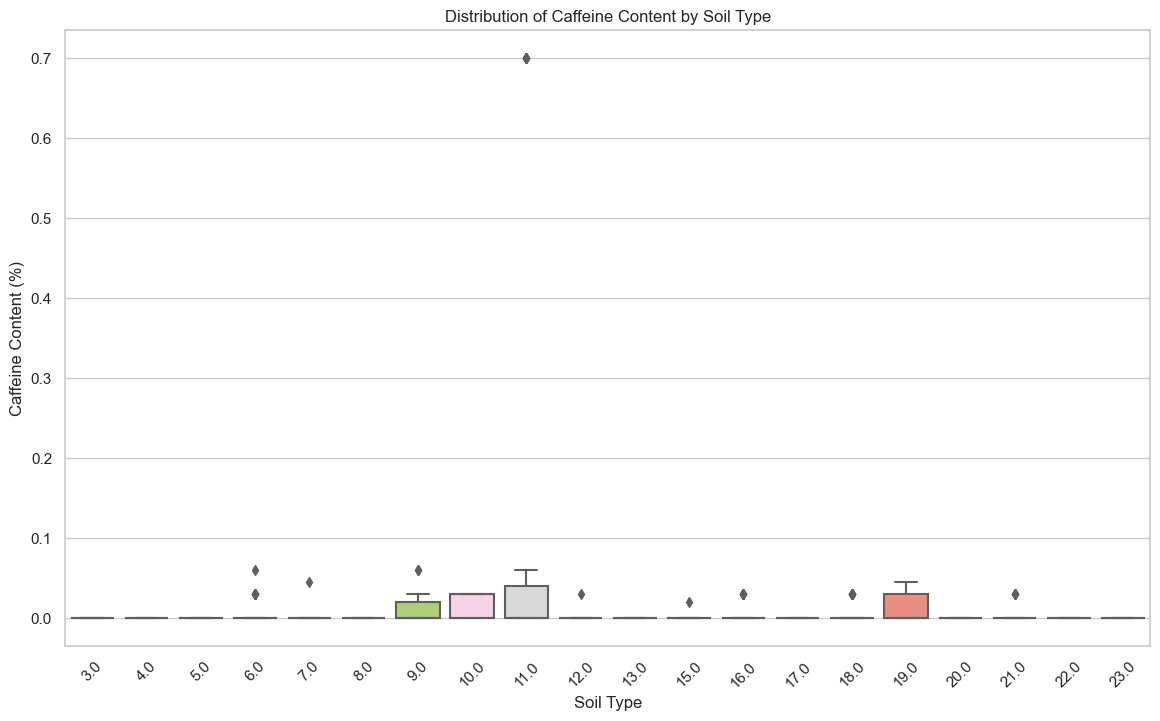

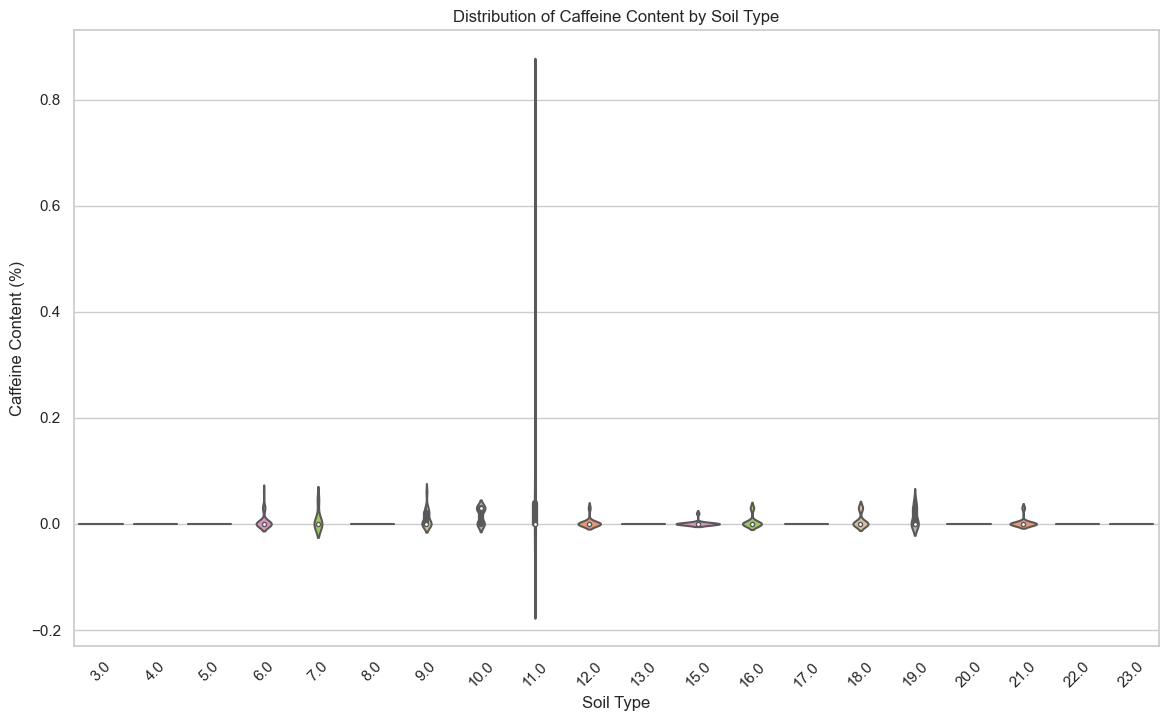

In [12]:
# Set the plot style
sns.set(style="whitegrid")

# Create a box plot
plt.figure(figsize=(14, 8))
sns.boxplot(x='env_76_soi', y='caffeine_percent', data=df, palette='Set3')
plt.title('Distribution of Caffeine Content by Soil Type')
plt.xlabel('Soil Type')
plt.ylabel('Caffeine Content (%)')
plt.xticks(rotation=45)  # Rotate x-axis labels if needed for better visibility
plt.show()

# Create a violin plot
plt.figure(figsize=(14, 8))
sns.violinplot(x='env_76_soi', y='caffeine_percent', data=df, palette='Set2')
plt.title('Distribution of Caffeine Content by Soil Type')
plt.xlabel('Soil Type')
plt.ylabel('Caffeine Content (%)')
plt.xticks(rotation=45)  # Rotate x-axis labels if needed for better visibility
plt.show()

c:\Users\adm1\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\adm1\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\adm1\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


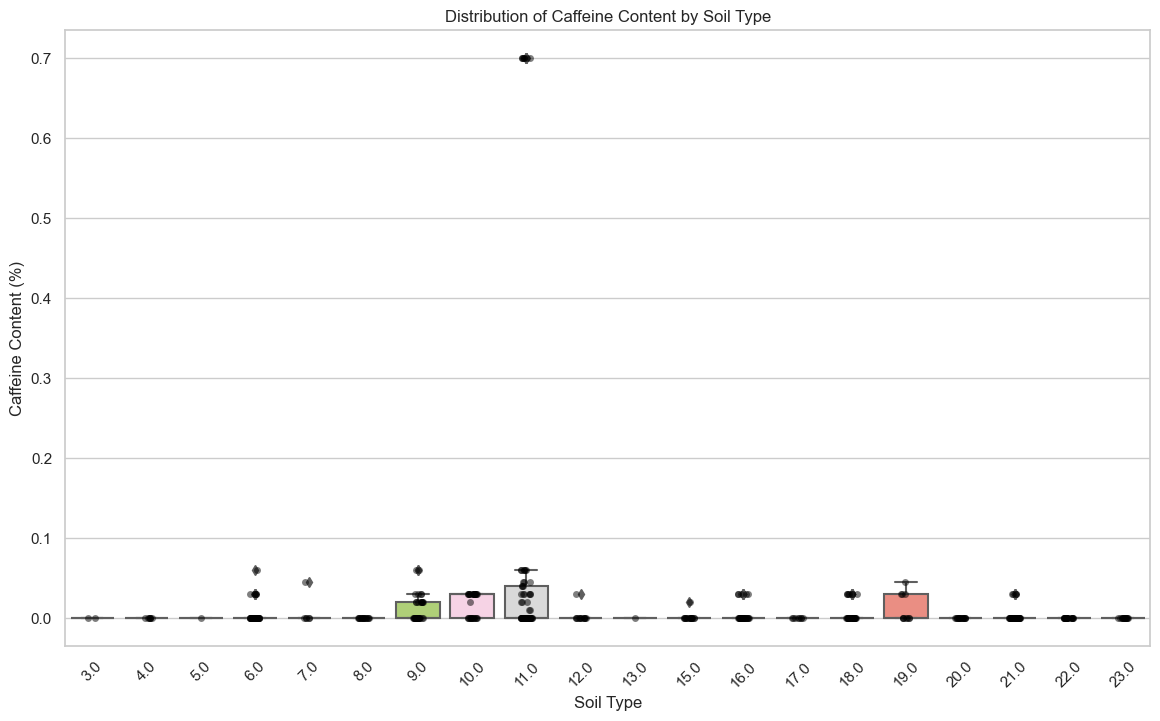

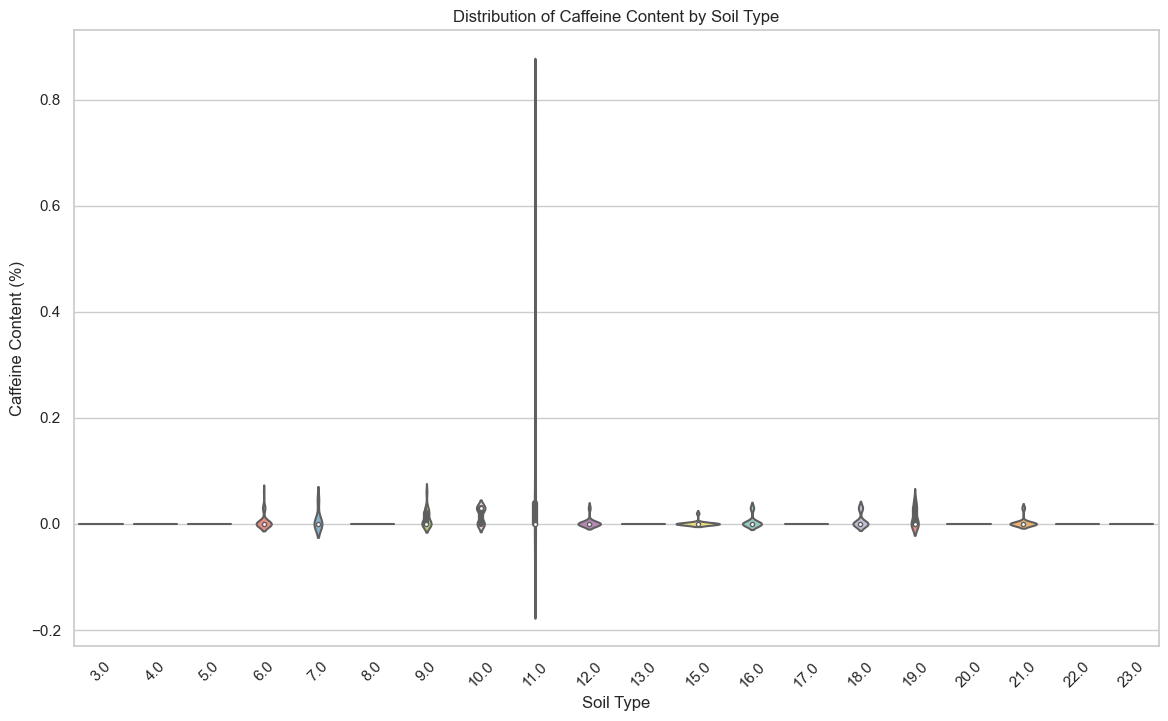

In [13]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Set the plot style
sns.set(style="whitegrid")

# Create a box plot with data points
plt.figure(figsize=(14, 8))
sns.boxplot(x='env_76_soi', y='caffeine_percent', data=df, palette='Set3')
sns.stripplot(x='env_76_soi', y='caffeine_percent', data=df, color='black', alpha=0.5, jitter=True)
plt.title('Distribution of Caffeine Content by Soil Type')
plt.xlabel('Soil Type')
plt.ylabel('Caffeine Content (%)')
plt.xticks(rotation=45)  # Rotate x-axis labels if needed for better visibility
plt.show()

# Create a violin plot
plt.figure(figsize=(14, 8))
sns.violinplot(x='env_76_soi', y='caffeine_percent', data=df, palette='Set3')
plt.title('Distribution of Caffeine Content by Soil Type')
plt.xlabel('Soil Type')
plt.ylabel('Caffeine Content (%)')
plt.xticks(rotation=45)  # Rotate x-axis labels if needed for better visibility
plt.show()


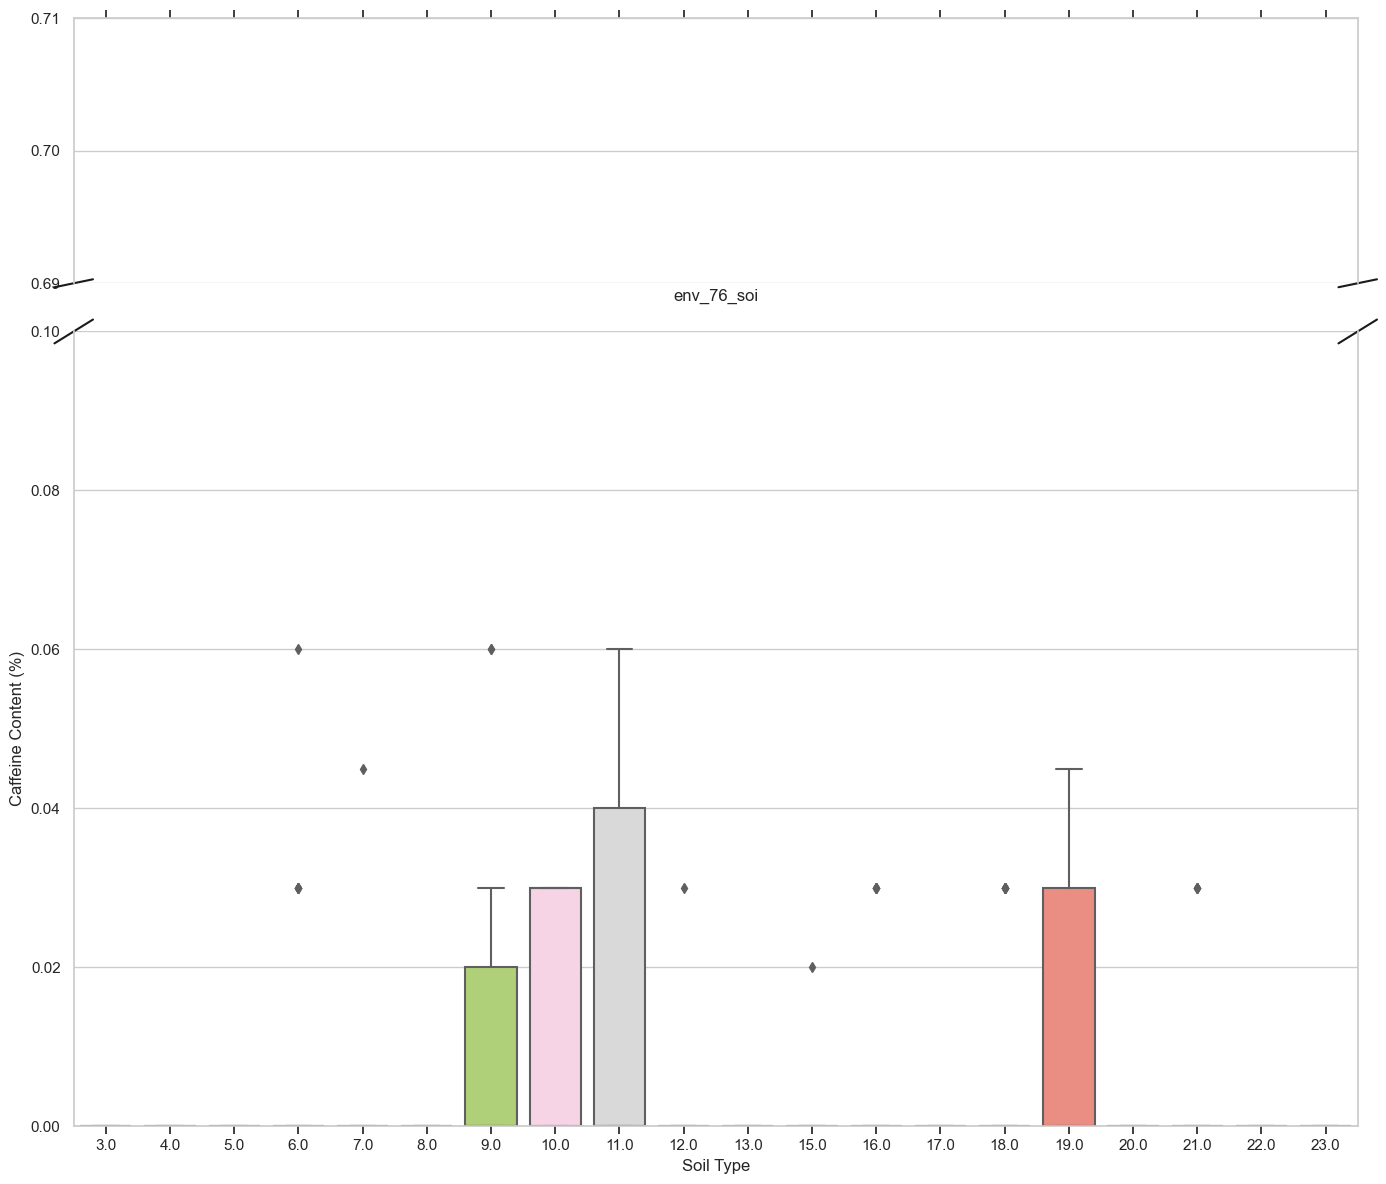

In [14]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming df is already defined and contains the necessary data

# Set the plot style
sns.set(style="whitegrid")

# Create a figure with subplots for the box plots (2 subplots per plot)
fig, axes = plt.subplots(2, 1, sharex=True, figsize=(14, 12),
                         gridspec_kw={'height_ratios': [1, 3]})

# Box plot with broken y-axis
ax1 = axes[0]  # Top plot for box plot
ax2 = axes[1]  # Bottom plot for box plot

# Top plot (focused on 0.69 to 0.71 range)
sns.boxplot(x='env_76_soi', y='caffeine_percent', data=df, palette='Set3', ax=ax1, showfliers=False)
ax1.set_ylim(0.69, 0.71)  # Display a small range above the break
ax1.set_yticks(np.arange(0.69, 0.71, 0.01))  # Adjust interval for the narrow section

# Bottom plot (below 0.1)
sns.boxplot(x='env_76_soi', y='caffeine_percent', data=df, palette='Set3', ax=ax2)
ax2.set_ylim(0, 0.1)  # Emphasize the main range
ax2.set_yticks(np.arange(0, 0.11, 0.02))  # Set interval for the bottom part

# Formatting for better visualization
ax1.spines['bottom'].set_visible(False)
ax2.spines['top'].set_visible(False)
ax1.xaxis.tick_top()
ax1.tick_params(labeltop=False)  # Don't put tick labels at the top
ax2.xaxis.tick_bottom()

# Add diagonal lines to indicate the break in the y-axis
d = .015  # How big to make the diagonal lines in axes coordinates
kwargs = dict(transform=ax1.transAxes, color='k', clip_on=False)
ax1.plot((-d, +d), (-d, +d), **kwargs)  # Top-left diagonal
ax1.plot((1 - d, 1 + d), (-d, +d), **kwargs)  # Top-right diagonal

kwargs.update(transform=ax2.transAxes)  # Switch to the bottom axes
ax2.plot((-d, +d), (1 - d, 1 + d), **kwargs)  # Bottom-left diagonal
ax2.plot((1 - d, 1 + d), (1 - d, 1 + d), **kwargs)  # Bottom-right diagonal

# Set labels and titles for box plot
ax2.set_xlabel('Soil Type')
ax2.set_ylabel('Caffeine Content (%)')
ax1.set_ylabel('')  # Remove y-axis label from the top plot

# Adjust layout to avoid overlap
plt.tight_layout()
plt.show()


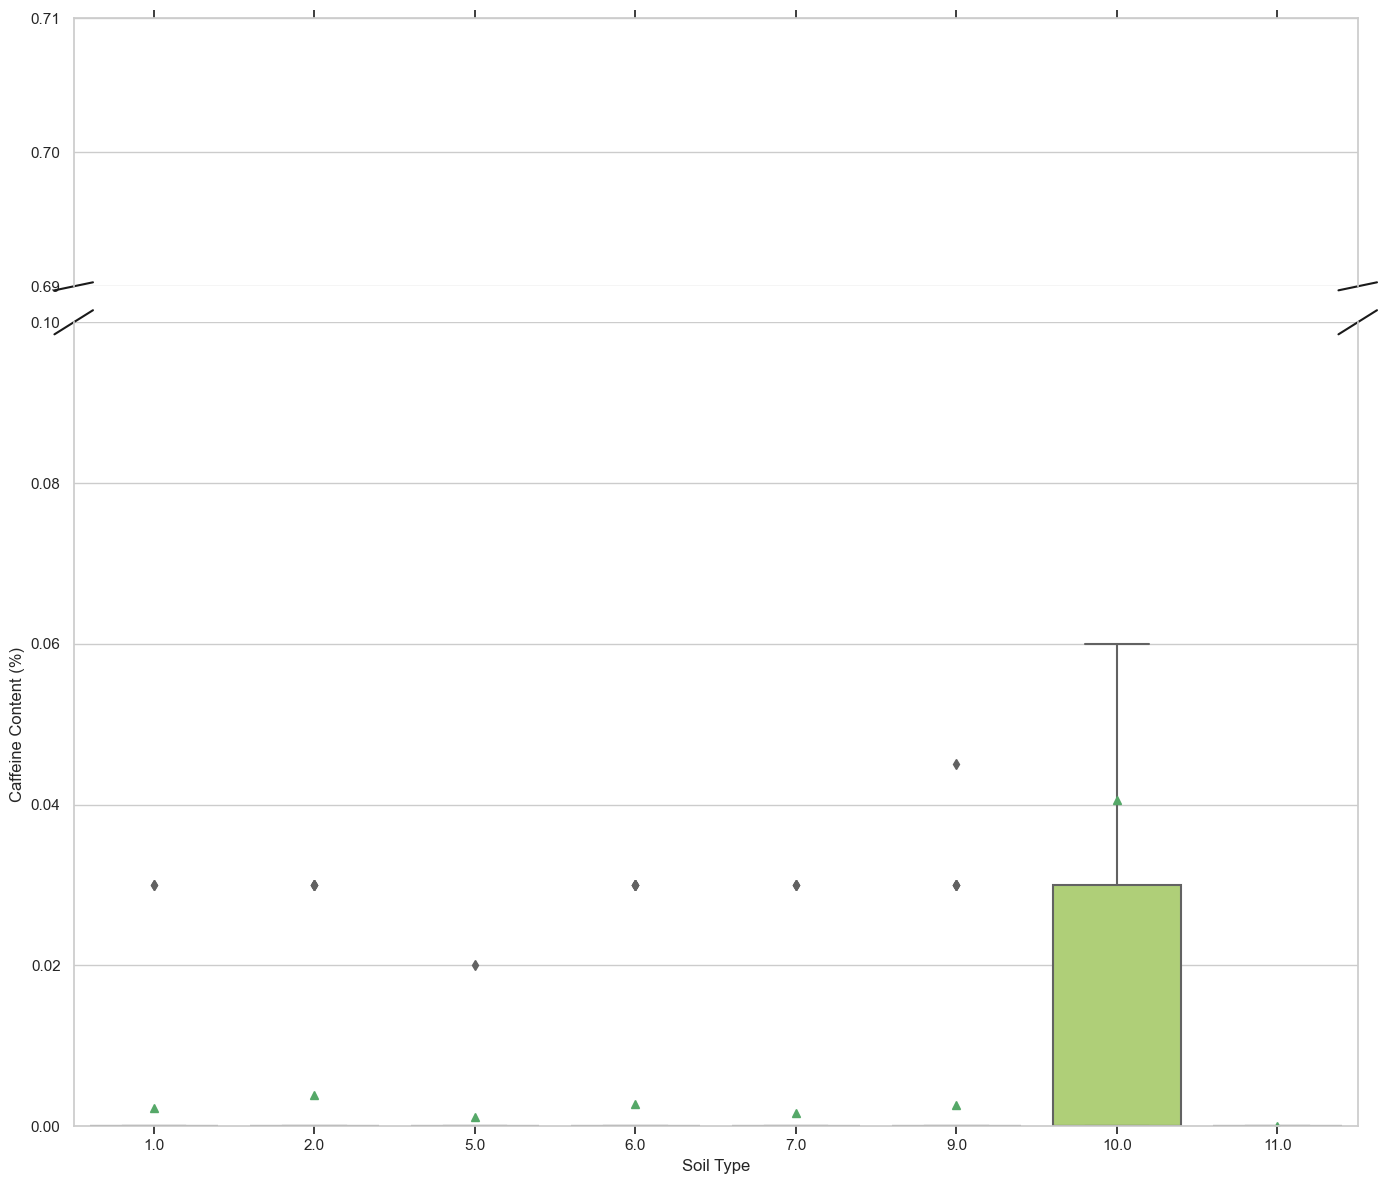

In [15]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming df is already defined and contains the necessary data

# Handle missing values by dropping rows with missing 'caffeine_percent' values
df = df.dropna(subset=['caffeine_percent'])

# Set the plot style
sns.set(style="whitegrid")

# Create a figure with subplots for the box plots (2 subplots per plot)
fig, axes = plt.subplots(2, 1, sharex=True, figsize=(14, 12),
                         gridspec_kw={'height_ratios': [1, 3]})

# Box plot with broken y-axis
ax1 = axes[0]  # Top plot for box plot
ax2 = axes[1]  # Bottom plot for box plot

# Top plot (focused on 0.69 to 0.71 range)
sns.boxplot(x='env_75_geo', y='caffeine_percent', data=df, palette='Set3', ax=ax1, showfliers=False, showmeans=True)
ax1.set_ylim(0.69, 0.71)  # Display a small range above the break
ax1.set_yticks(np.arange(0.69, 0.71, 0.01))  # Adjust interval for the narrow section

# Bottom plot (below 0.1)
sns.boxplot(x='env_75_geo', y='caffeine_percent', data=df, palette='Set3', ax=ax2, showmeans=True)
ax2.set_ylim(0, 0.1)  # Emphasize the main range
ax2.set_yticks(np.arange(0, 0.11, 0.02))  # Set interval for the bottom part

# Formatting for better visualization
ax1.spines['bottom'].set_visible(False)
ax2.spines['top'].set_visible(False)
ax1.xaxis.tick_top()
ax1.tick_params(labeltop=False)  # Don't put tick labels at the top
ax2.xaxis.tick_bottom()

# Add diagonal lines to indicate the break in the y-axis
d = .015  # How big to make the diagonal lines in axes coordinates
kwargs = dict(transform=ax1.transAxes, color='k', clip_on=False)
ax1.plot((-d, +d), (-d, +d), **kwargs)  # Top-left diagonal
ax1.plot((1 - d, 1 + d), (-d, +d), **kwargs)  # Top-right diagonal

kwargs.update(transform=ax2.transAxes)  # Switch to the bottom axes
ax2.plot((-d, +d), (1 - d, 1 + d), **kwargs)  # Bottom-left diagonal
ax2.plot((1 - d, 1 + d), (1 - d, 1 + d), **kwargs)  # Bottom-right diagonal

# Set labels and titles for box plot
ax2.set_xlabel('Soil Type')
ax2.set_ylabel('Caffeine Content (%)')
ax1.set_ylabel('')  # Remove y-axis label from the top plot
ax1.set_xlabel('')  # Remove x-axis label from the top plot

# Adjust layout to avoid overlap
plt.tight_layout()
plt.show()


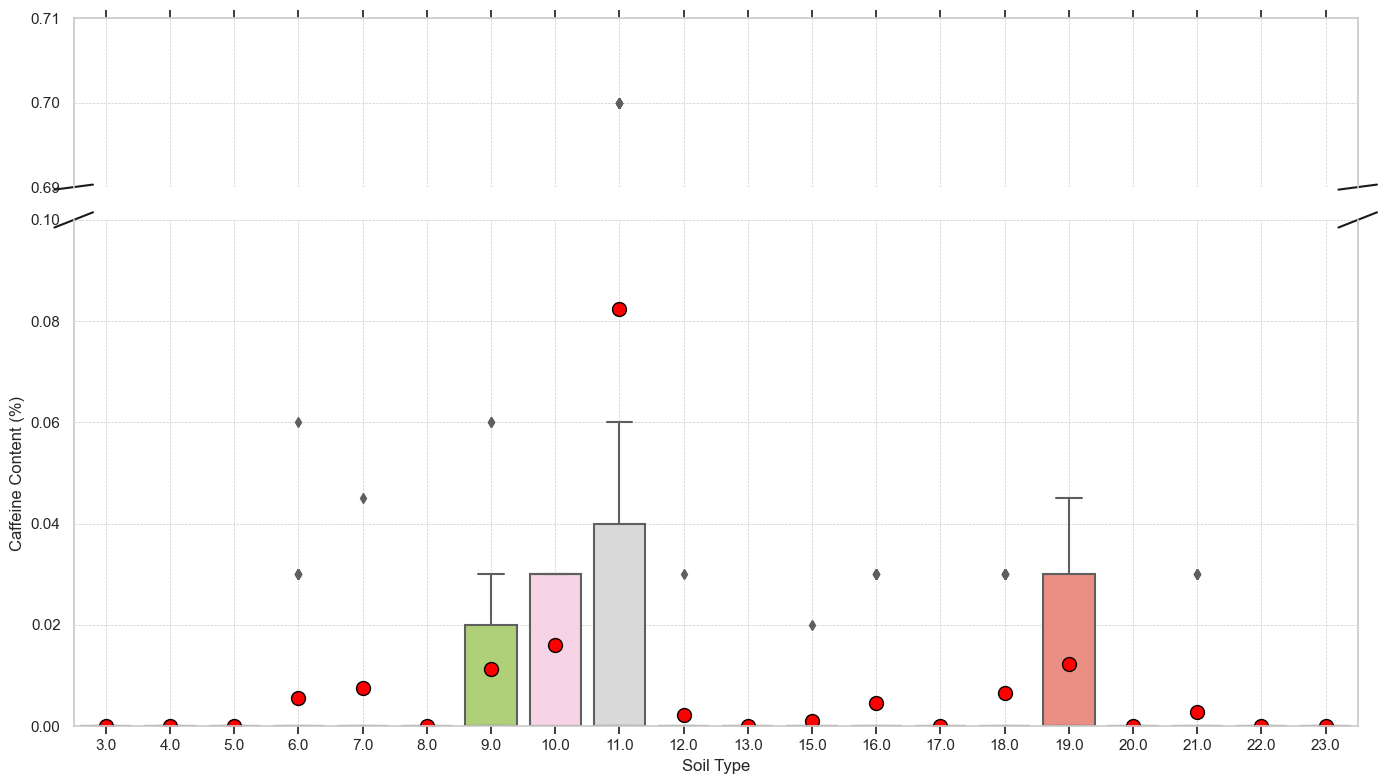

In [16]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

meanprops = {
    'marker': 'o',  # Change the marker to 'o' (circle), 's' (square), etc.
    'markerfacecolor': 'red',  # Change the fill color of the marker
    'markeredgecolor': 'black',  # Change the edge color of the marker
    'markersize': 10  # Change the size of the marker
}

# Set the plot style
sns.set(style="whitegrid")

# Create a figure with subplots for the box plot and violin plot (2 subplots per plot)
fig, axes = plt.subplots(2, 1, sharex=True, figsize=(14, 8),
                         gridspec_kw={'height_ratios': [1, 3]})

# Box plot with broken y-axis
ax1 = axes[0]  # Top plot for box plot
ax2 = axes[1]  # Bottom plot for box plot

# Top plot (focused on 0.69 to 0.71 range)
sns.boxplot(x='env_76_soi', y='caffeine_percent', data=df, palette='Set3', ax=ax1, showmeans=True, meanprops=meanprops)
ax1.set_ylim(0.69, 0.71)  # Display a small range above the break
ax1.set_yticks(np.arange(0.69, 0.71, 0.01))  # Adjust interval for the narrow section

# Bottom plot (below 0.1)
sns.boxplot(x='env_76_soi', y='caffeine_percent', data=df, palette='Set3', ax=ax2, showmeans=True, meanprops=meanprops)
ax2.set_ylim(0, 0.1)  # Emphasize the main range
ax2.set_yticks(np.arange(0, 0.11, 0.02))  # Set interval for the bottom part

# Formatting for better visualization
ax1.spines['bottom'].set_visible(False)
ax2.spines['top'].set_visible(False)
ax1.xaxis.tick_top()
ax1.tick_params(labeltop=False)  # Don't put tick labels at the top
ax2.xaxis.tick_bottom()

# Add diagonal lines to indicate the break in the y-axis
d = .015  # How big to make the diagonal lines in axes coordinates
kwargs = dict(transform=ax1.transAxes, color='k', clip_on=False)
ax1.plot((-d, +d), (-d, +d), **kwargs)  # Top-left diagonal
ax1.plot((1 - d, 1 + d), (-d, +d), **kwargs)  # Top-right diagonal

kwargs.update(transform=ax2.transAxes)  # Switch to the bottom axes
ax2.plot((-d, +d), (1 - d, 1 + d), **kwargs)  # Bottom-left diagonal
ax2.plot((1 - d, 1 + d), (1 - d, 1 + d), **kwargs)  # Bottom-right diagonal

# Set labels and titles for box plot
ax2.set_xlabel('Soil Type')
ax2.set_ylabel('Caffeine Content (%)')
ax1.set_ylabel('')  # Remove y-axis label from the top plot
ax1.set_xlabel('')  # Remove y-axis label from the top plot
ax1.grid(True, which='both', linestyle='--', linewidth=0.5)
ax2.grid(True, which='both', linestyle='--', linewidth=0.5)

# # Violin plot with broken y-axis
# ax3 = axes[2]  # Top plot for violin plot
# ax4 = axes[3]  # Bottom plot for violin plot

# # Top plot (focused on 0.69 to 0.71 range)
# sns.violinplot(x='env_76_soi', y='caffeine_percent', data=df, palette='Set3', ax=ax3)
# ax3.set_ylim(0.69, 0.71)  # Display a small range above the break
# ax3.set_yticks(np.arange(0.69, 0.71, 0.01))  # Adjust interval for the narrow section

# # Bottom plot (below 0.1)
# sns.violinplot(x='env_76_soi', y='caffeine_percent', data=df, palette='Set3', ax=ax4)
# ax4.set_ylim(0, 0.1)  # Emphasize the main range
# ax4.set_yticks(np.arange(0, 0.11, 0.02))  # Set interval for the bottom part

# # Formatting for better visualization
# ax3.spines['bottom'].set_visible(False)
# ax4.spines['top'].set_visible(False)
# ax3.xaxis.tick_top()
# ax3.tick_params(labeltop=False)  # Don't put tick labels at the top
# ax4.xaxis.tick_bottom()

# # Add diagonal lines to indicate the break in the y-axis
# kwargs = dict(transform=ax3.transAxes, color='k', clip_on=False)
# ax3.plot((-d, +d), (-d, +d), **kwargs)  # Top-left diagonal
# ax3.plot((1 - d, 1 + d), (-d, +d), **kwargs)  # Top-right diagonal

# kwargs.update(transform=ax4.transAxes)  # Switch to the bottom axes
# ax4.plot((-d, +d), (1 - d, 1 + d), **kwargs)  # Bottom-left diagonal
# ax4.plot((1 - d, 1 + d), (1 - d, 1 + d), **kwargs)  # Bottom-right diagonal

# # Set labels and titles for violin plot
# ax4.set_xlabel('Soil Type')
# ax4.set_ylabel('Caffeine Content (%)')
# ax3.set_ylabel('')  # Remove y-axis label from the top plot
# ax3.set_xlabel('')  # Remove y-axis label from the top plot


# Adjust layout to avoid overlap
plt.tight_layout()
plt.show()


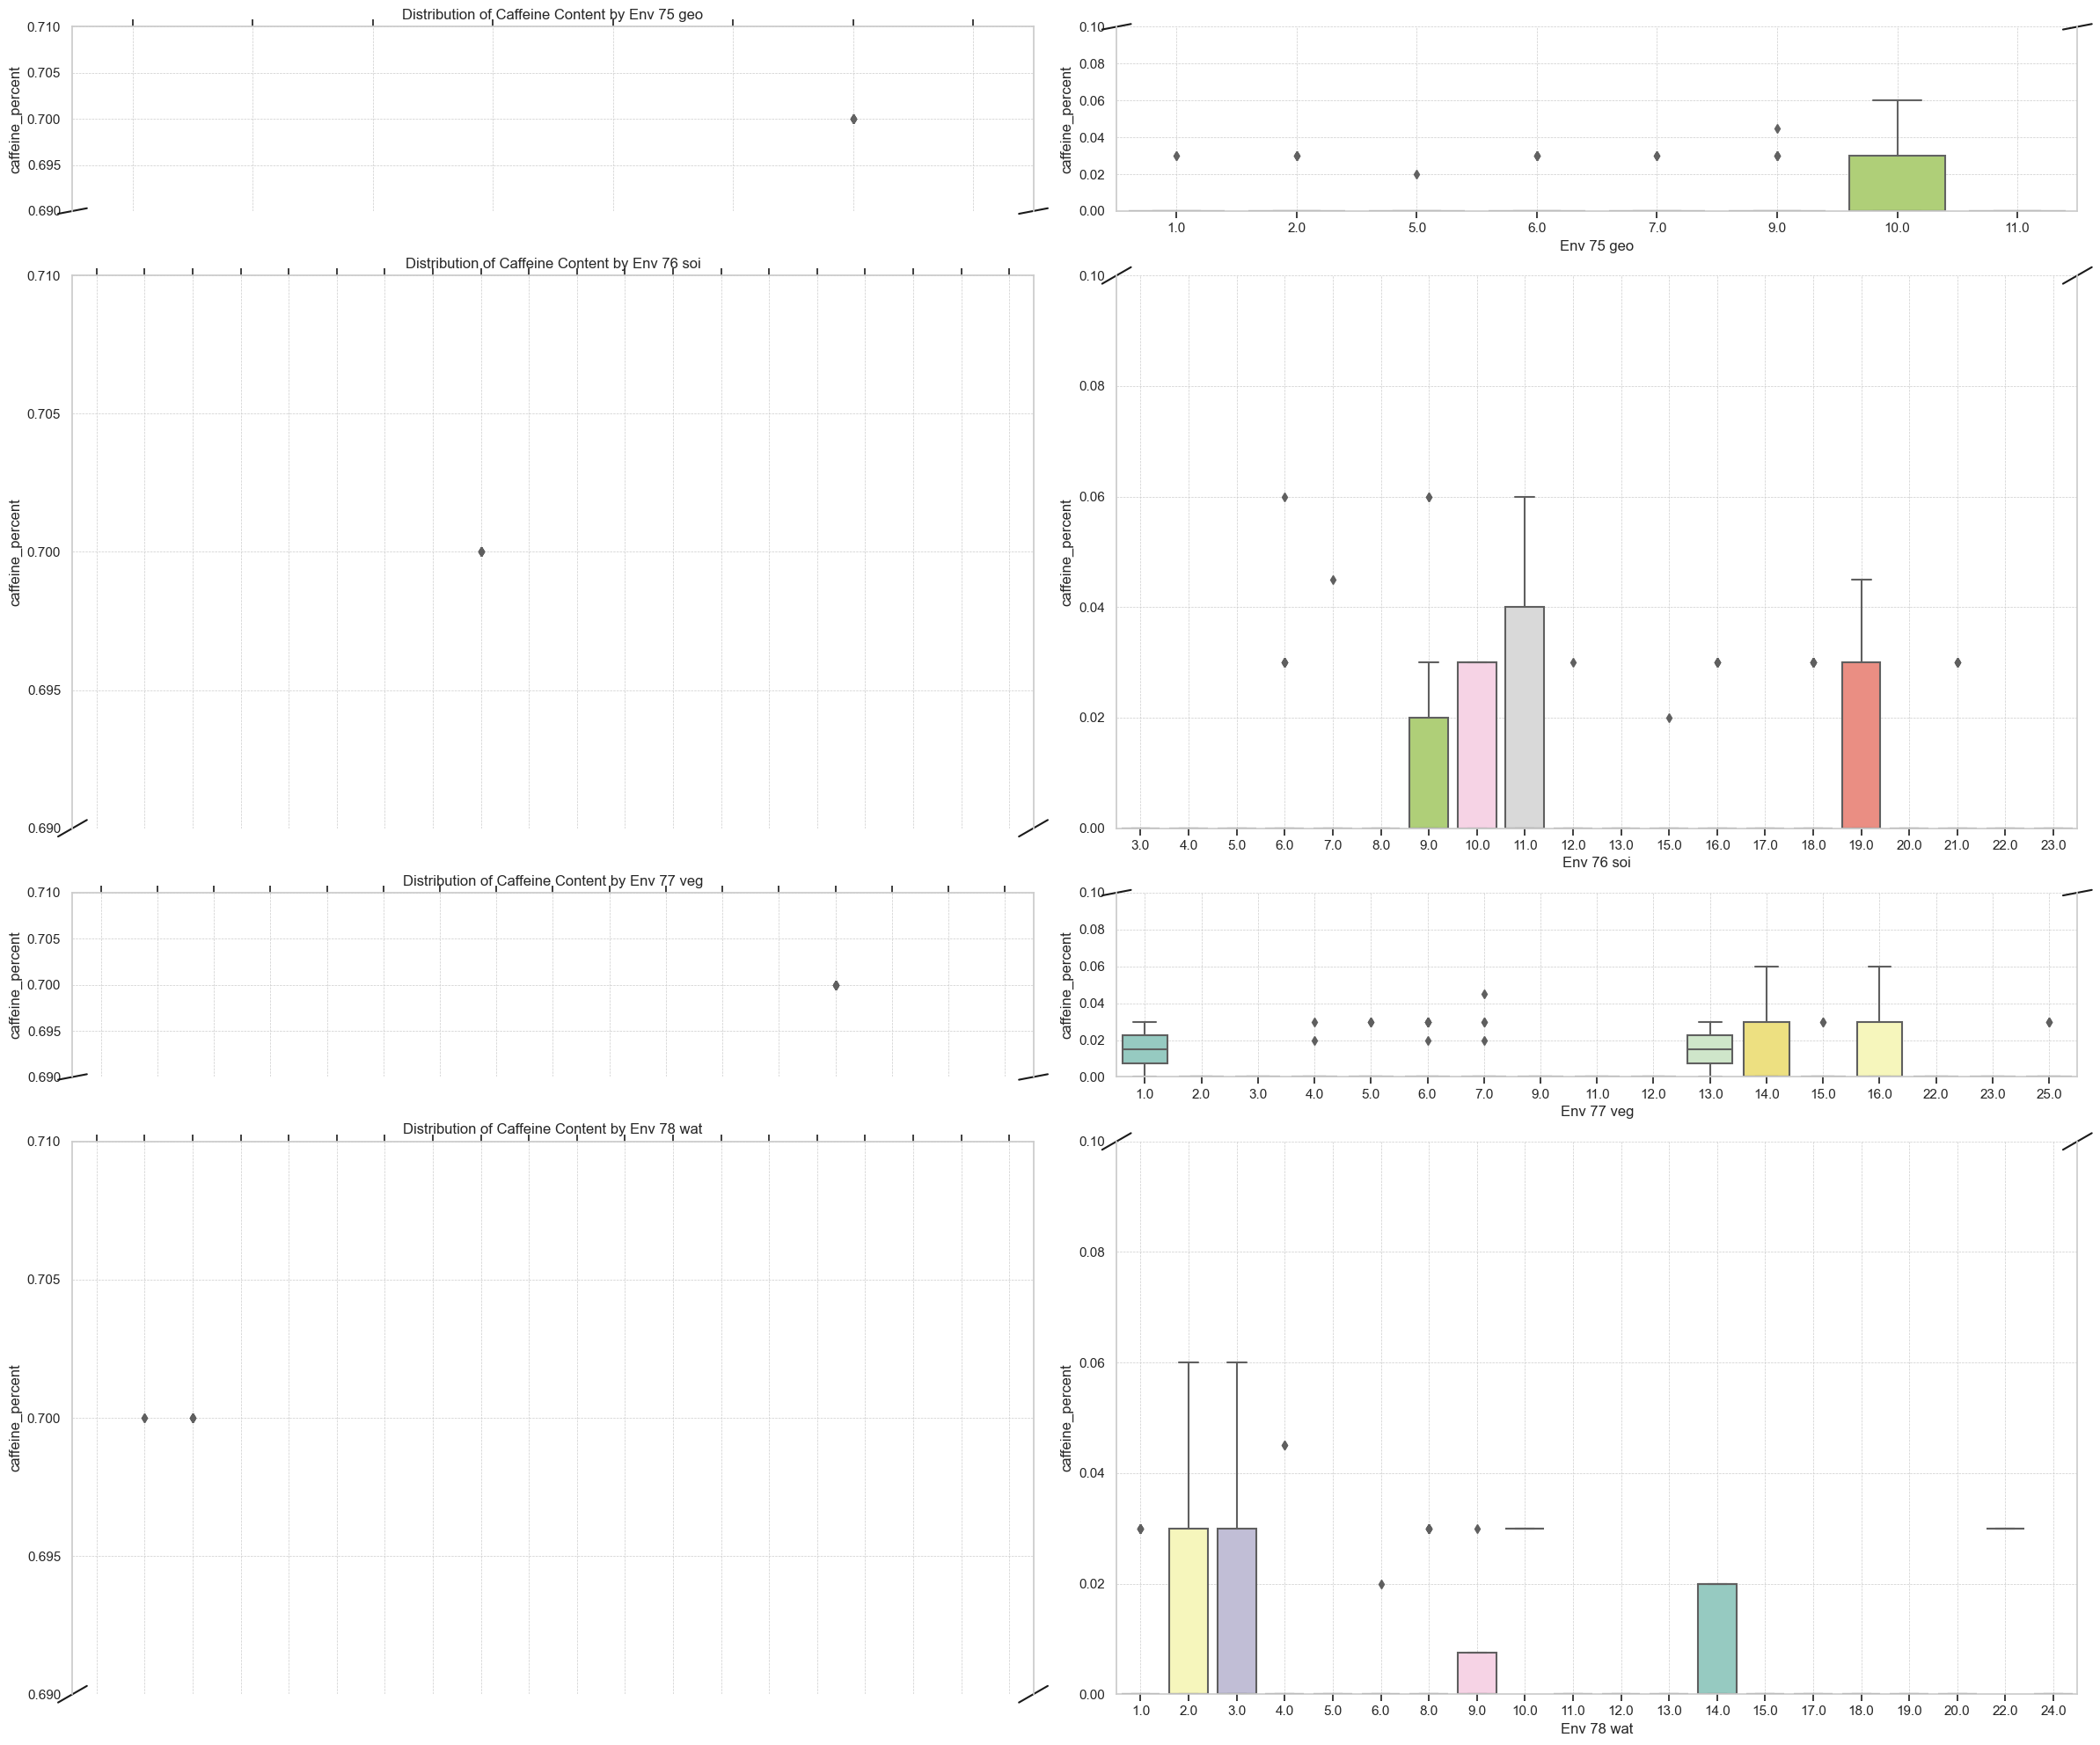

In [17]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# List of categorical columns you want to visualize
categorical_columns = ['env_75_geo', 'env_76_soi', 'env_77_veg', 'env_78_wat']

# Create a figure with a 2x2 grid of subplots (2 subplots per variable)
fig, axes = plt.subplots(4, 2, figsize=(24, 20), gridspec_kw={'height_ratios': [1, 3, 1, 3]})

# Flatten the axes for easier iteration
axes = axes.flatten()

# Loop through each column and create a box plot with a broken y-axis
for i, column in enumerate(categorical_columns):
    top_ax = axes[i * 2]  # Top plot
    bottom_ax = axes[i * 2 + 1]  # Bottom plot
    
    # Top plot (focused on 0.69 to 0.71 range)
    sns.boxplot(x=column, y='caffeine_percent', data=df, palette='Set3', ax=top_ax)
    top_ax.set_ylim(0.69, 0.71)  # Display a small range above the break
    top_ax.set_yticks(np.arange(0.69, 0.71, 0.005))  # Adjust interval for the narrow section
    top_ax.spines['bottom'].set_visible(False)
    top_ax.xaxis.tick_top()
    top_ax.tick_params(labeltop=False)
    top_ax.set_xlabel('')  # Remove x-axis label from the top plot
    top_ax.grid(True, which='both', linestyle='--', linewidth=0.5)  # Show grid in the background

    # Bottom plot (below 0.1)
    sns.boxplot(x=column, y='caffeine_percent', data=df, palette='Set3', ax=bottom_ax)
    bottom_ax.set_ylim(0, 0.1)  # Emphasize the main range
    bottom_ax.set_yticks(np.arange(0, 0.11, 0.02))  # Set interval for the bottom part
    bottom_ax.spines['top'].set_visible(False)
    bottom_ax.xaxis.tick_bottom()
    bottom_ax.set_xlabel(column.replace('_', ' ').capitalize())  # Add x-axis label only to the bottom plot
    bottom_ax.grid(True, which='both', linestyle='--', linewidth=0.5)  # Show grid in the background

    # Add diagonal lines to indicate the break in the y-axis for top and bottom plots
    d = .015  # How big to make the diagonal lines in axes coordinates
    kwargs = dict(transform=top_ax.transAxes, color='k', clip_on=False)
    top_ax.plot((-d, +d), (-d, +d), **kwargs)  # Top-left diagonal
    top_ax.plot((1 - d, 1 + d), (-d, +d), **kwargs)  # Top-right diagonal

    kwargs.update(transform=bottom_ax.transAxes)  # Switch to the bottom axes
    bottom_ax.plot((-d, +d), (1 - d, 1 + d), **kwargs)  # Bottom-left diagonal
    bottom_ax.plot((1 - d, 1 + d), (1 - d, 1 + d), **kwargs)  # Bottom-right diagonal

    # Set titles for each pair of plots
    top_ax.set_title(f'Distribution of Caffeine Content by {column.replace("_", " ").capitalize()}')

# Adjust layout to avoid overlap
plt.tight_layout()
plt.show()


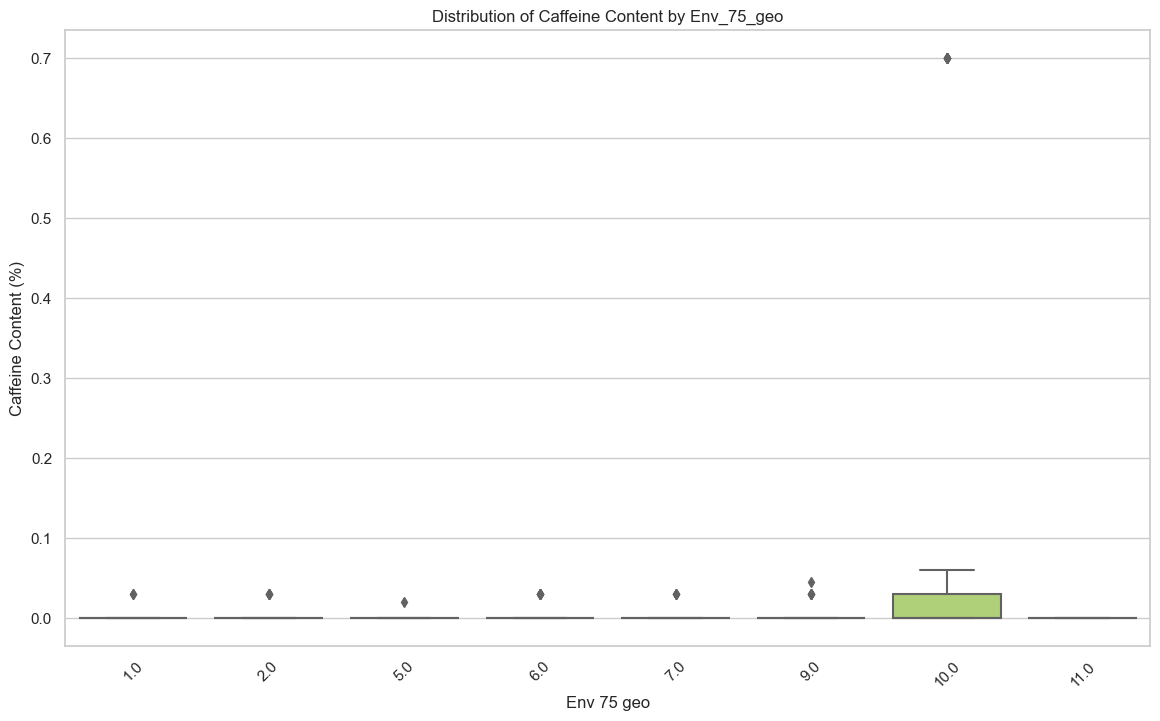

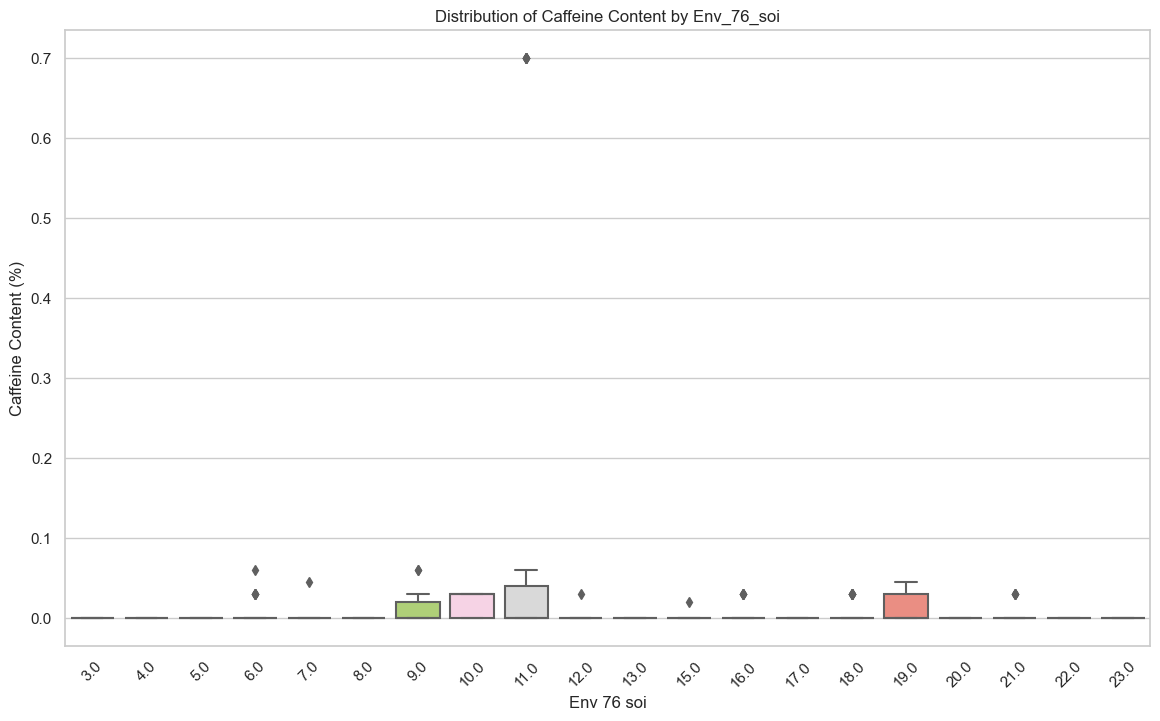

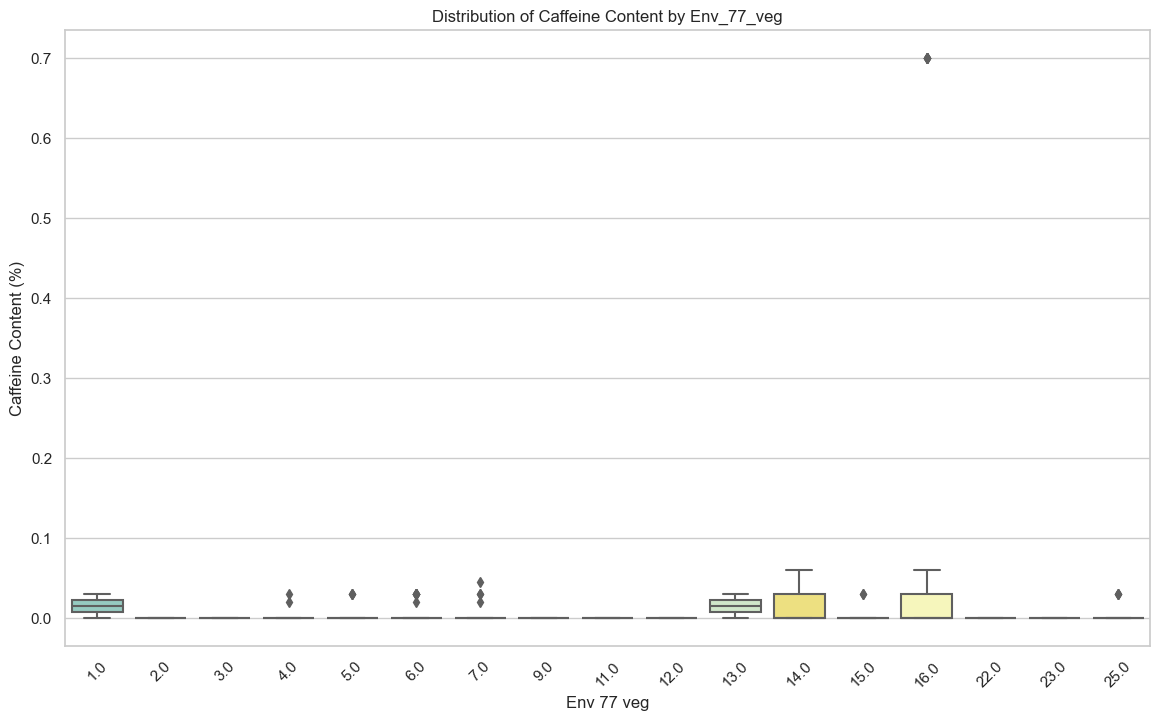

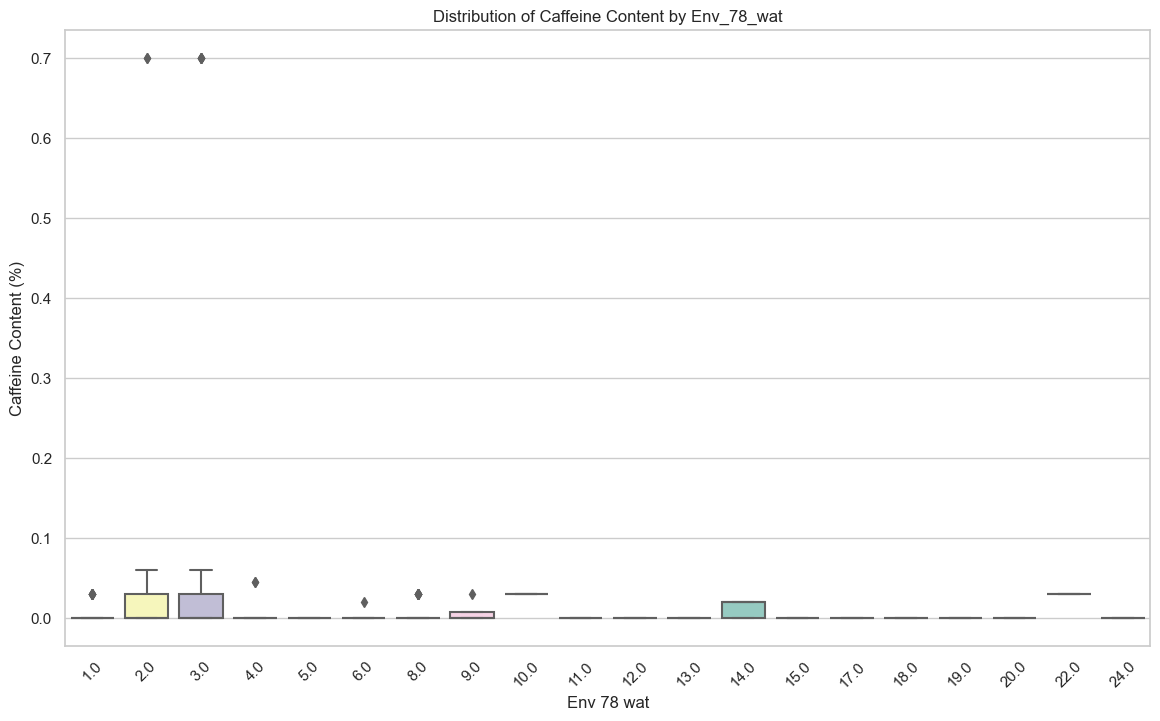

In [18]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Sample DataFrame (replace this with your actual data)
# df = pd.read_csv('your_data.csv')

# List of categorical columns you want to visualize
categorical_columns = ['env_75_geo', 'env_76_soi',  'env_77_veg',  'env_78_wat' ]

# Loop through each column and create a box plot or violin plot
for column in categorical_columns:
    plt.figure(figsize=(14, 8))
    sns.boxplot(x=column, y='caffeine_percent', data=df, palette='Set3')  # You can use sns.violinplot() for violin plots
    plt.title(f'Distribution of Caffeine Content by {column.capitalize()}')
    plt.xlabel(column.replace('_', ' ').capitalize())
    plt.ylabel('Caffeine Content (%)')
    plt.xticks(rotation=45)  # Rotate x-axis labels if needed
    plt.show()


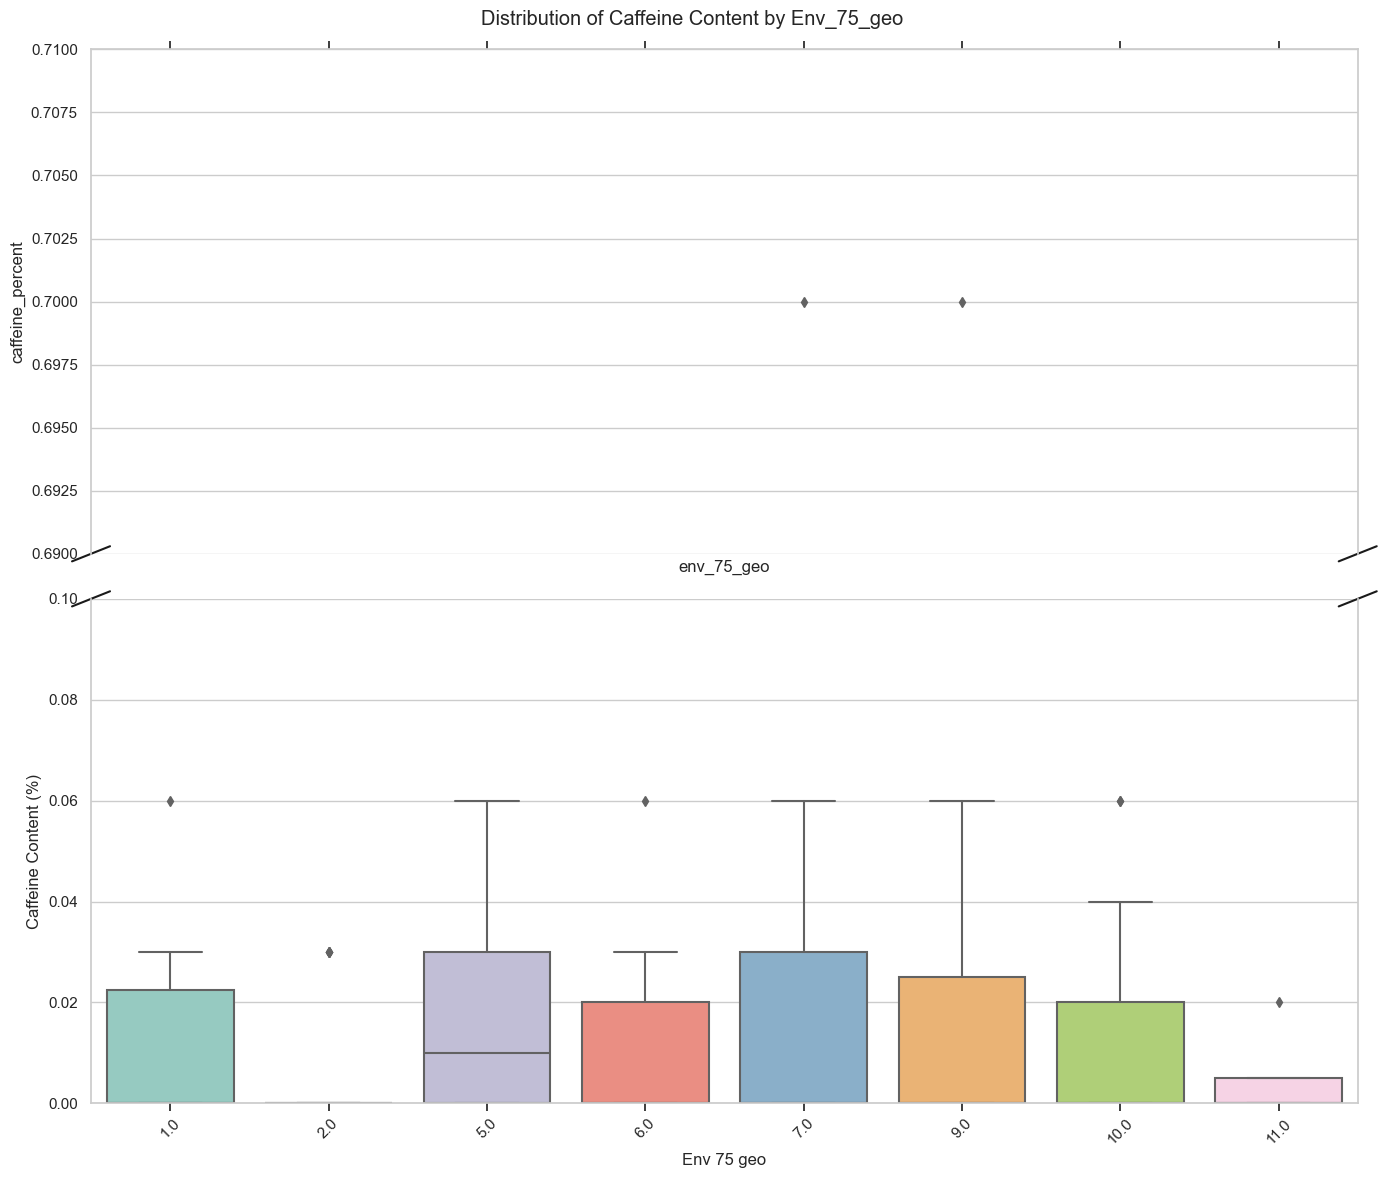

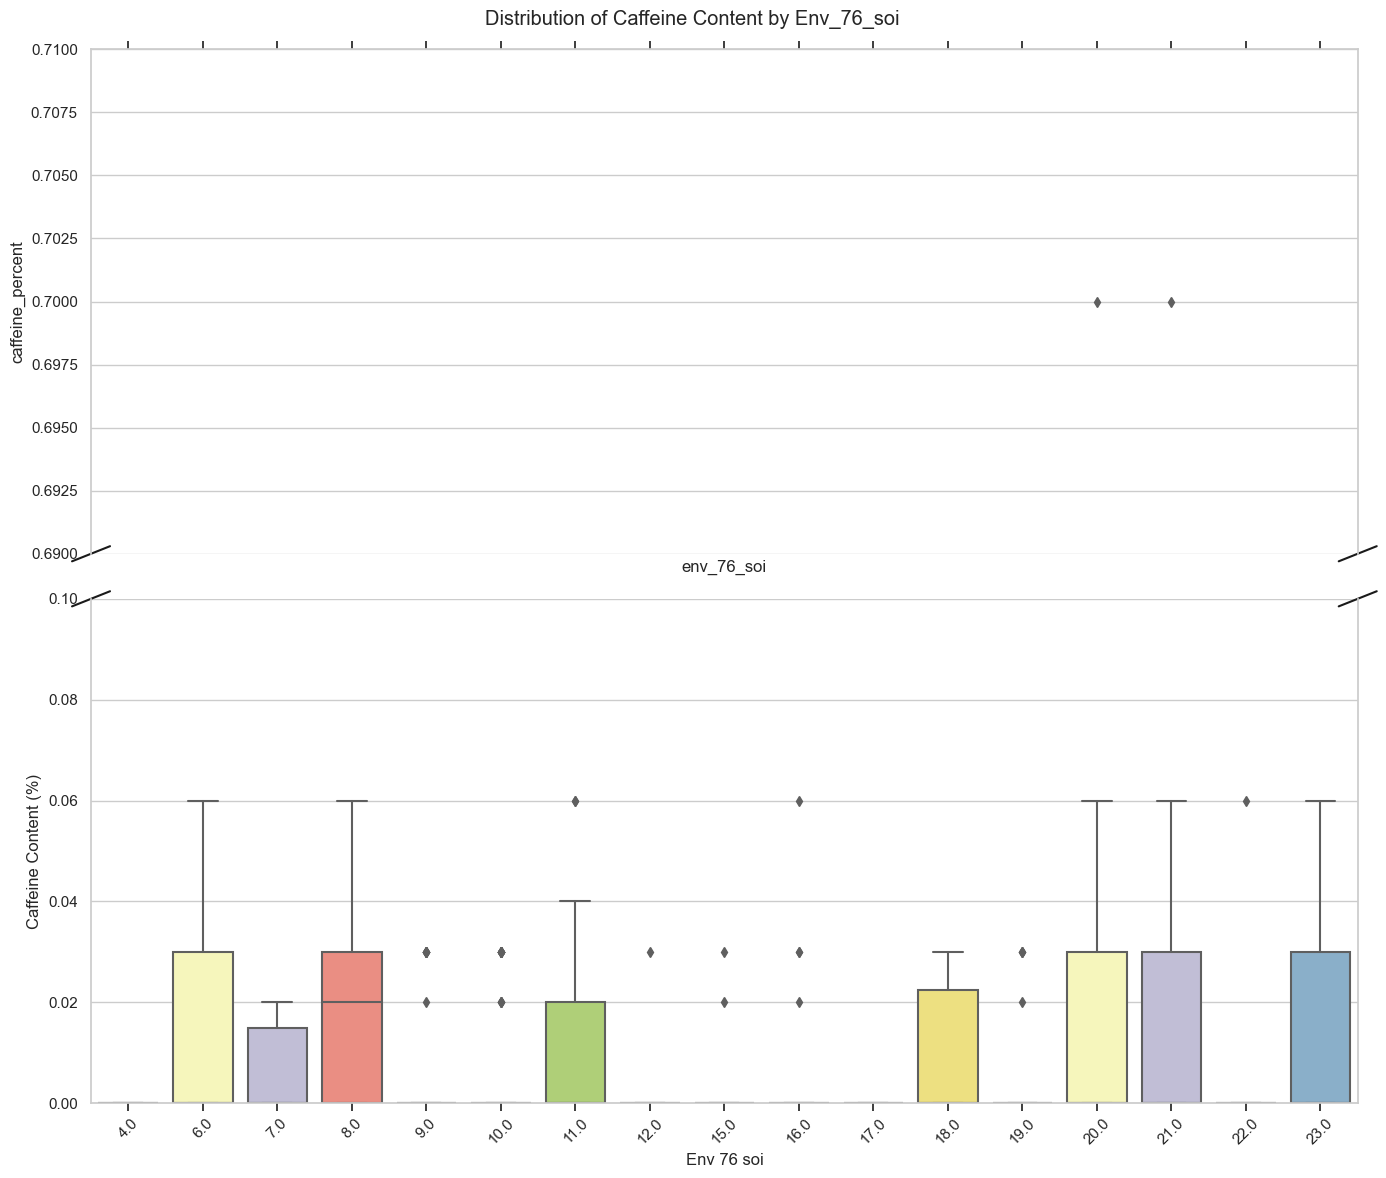

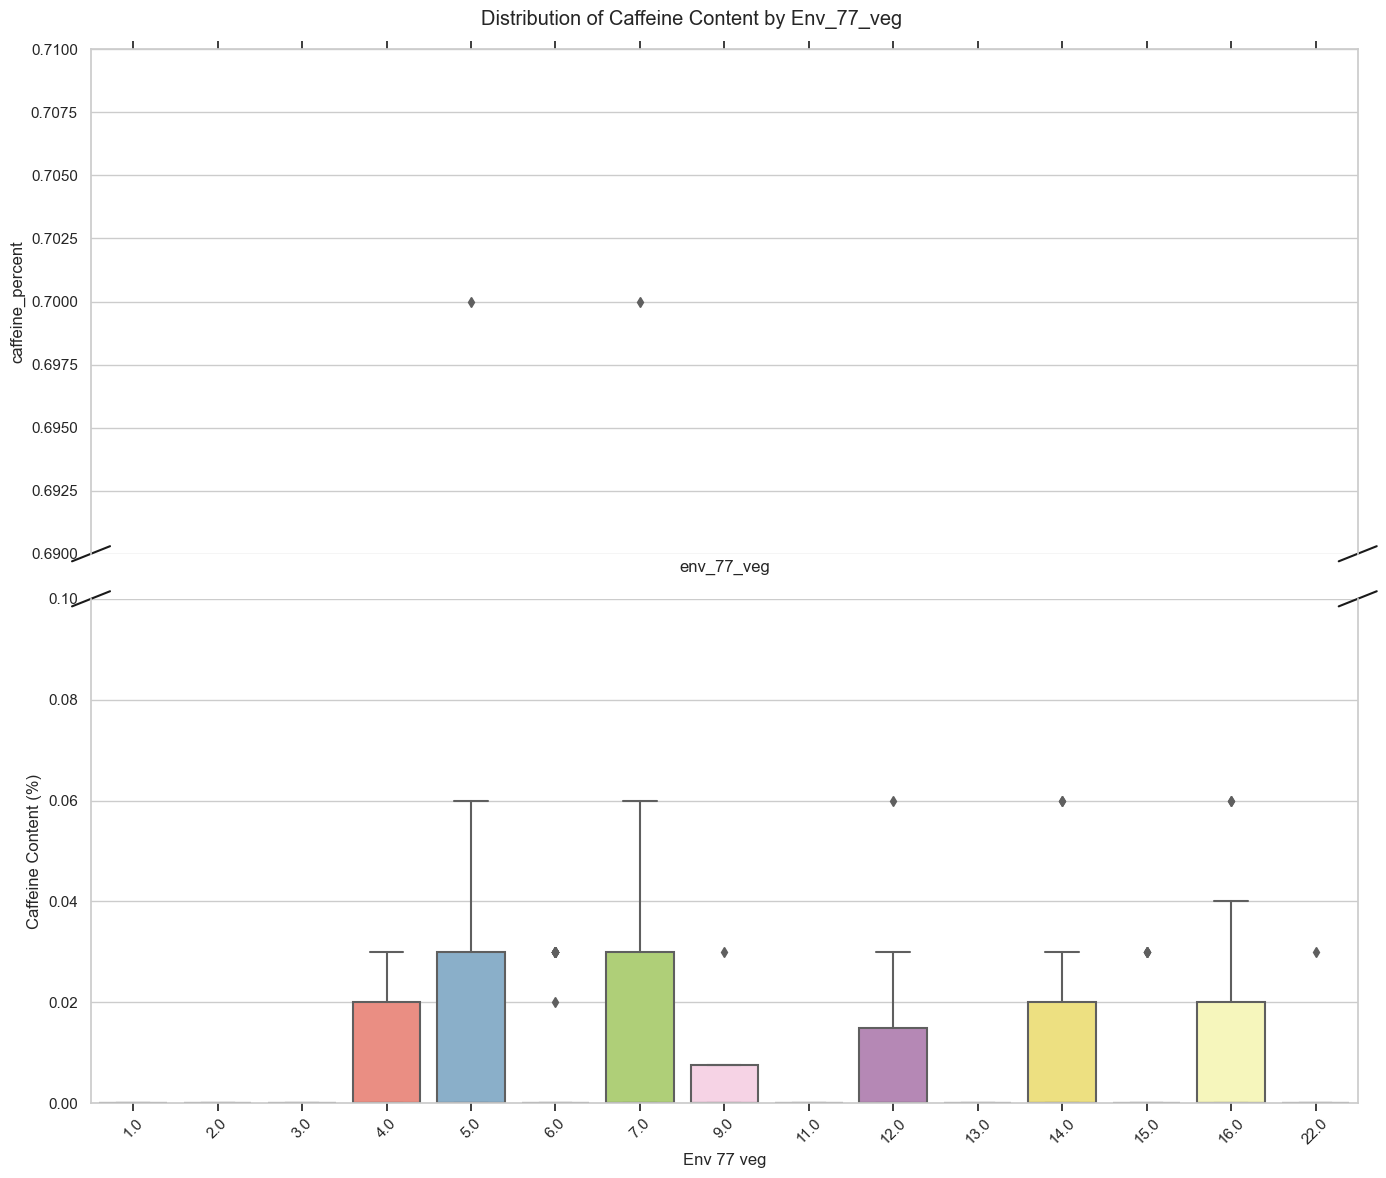

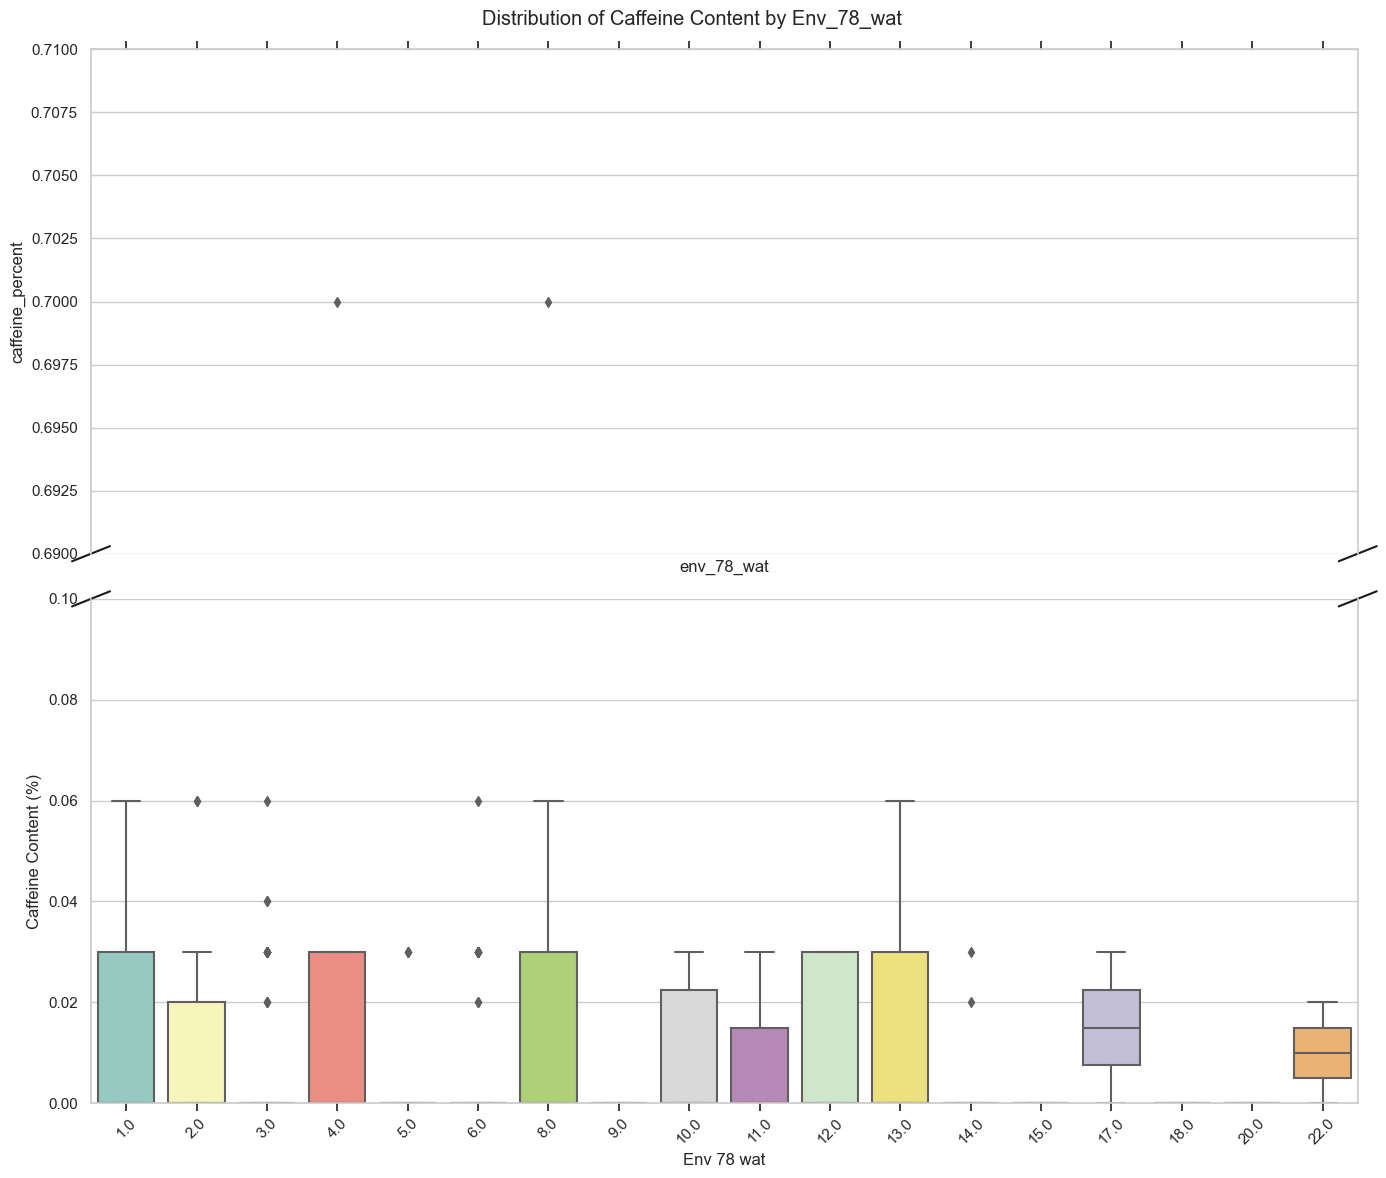

In [41]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# List of categorical columns you want to visualize
categorical_columns = ['env_75_geo', 'env_76_soi', 'env_77_veg', 'env_78_wat']

# Loop through each column and create a box plot with a broken y-axis
for column in categorical_columns:
    fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(14, 12) )#, gridspec_kw={'height_ratios': [1, 2]})
    
    # Top plot (above 0.65)
    sns.boxplot(x=column, y='caffeine_percent', data=df, palette='Set3', ax=ax1)
    ax1.set_ylim(0.69, 0.71)  # Adjust the upper limit as needed
    
    # Bottom plot (below 0.1)
    sns.boxplot(x=column, y='caffeine_percent', data=df, palette='Set3', ax=ax2)
    ax2.set_ylim(0, 0.1)  # Adjust the lower limit as needed

    # Formatting for better visualization
    ax1.spines['bottom'].set_visible(False)
    ax2.spines['top'].set_visible(False)
    ax1.xaxis.tick_top()
    ax1.tick_params(labeltop=False)  # Don't put tick labels at the top
    ax2.xaxis.tick_bottom()

    # Add diagonal lines to indicate the break in the y-axis
    d = .015  # How big to make the diagonal lines in axes coordinates
    kwargs = dict(transform=ax1.transAxes, color='k', clip_on=False)
    ax1.plot((-d, +d), (-d, +d), **kwargs)  # Top-left diagonal
    ax1.plot((1 - d, 1 + d), (-d, +d), **kwargs)  # Top-right diagonal

    kwargs.update(transform=ax2.transAxes)  # Switch to the bottom axes
    ax2.plot((-d, +d), (1 - d, 1 + d), **kwargs)  # Bottom-left diagonal
    ax2.plot((1 - d, 1 + d), (1 - d, 1 + d), **kwargs)  # Bottom-right diagonal

    # Set labels and titles
    ax2.set_xlabel(column.replace('_', ' ').capitalize())
    ax2.set_ylabel('Caffeine Content (%)')
    plt.suptitle(f'Distribution of Caffeine Content by {column.capitalize()}')
    plt.xticks(rotation=45)  # Rotate x-axis labels if needed
    
    plt.tight_layout()
    plt.show()


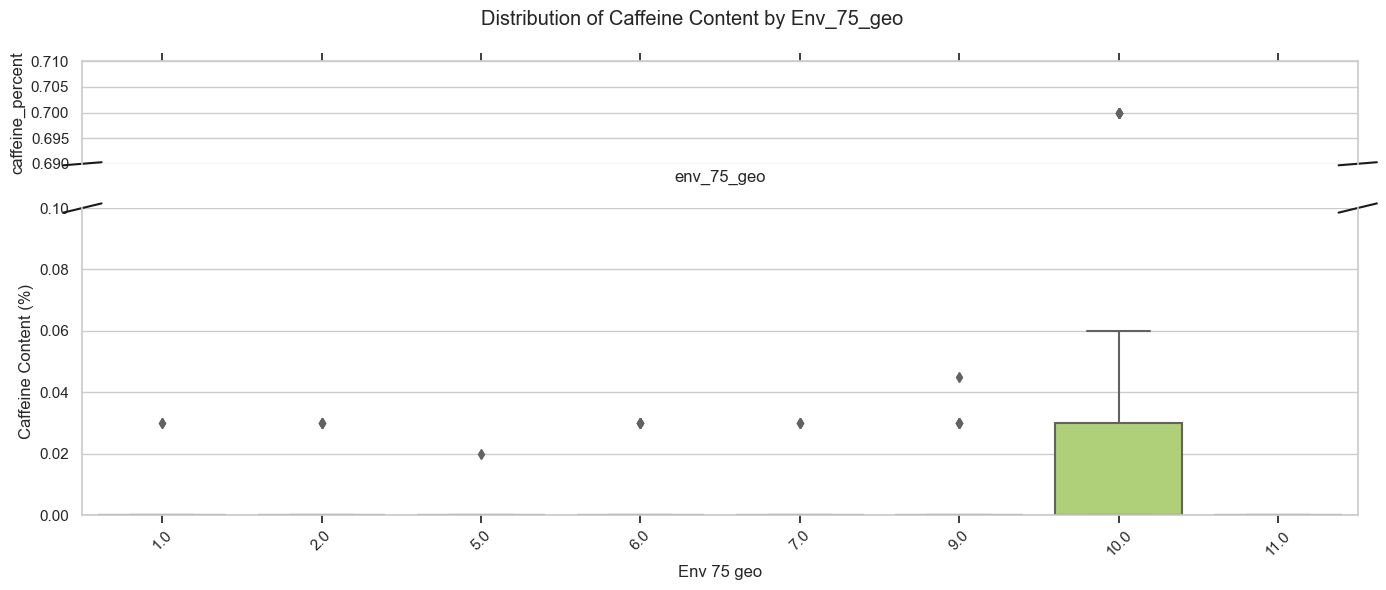

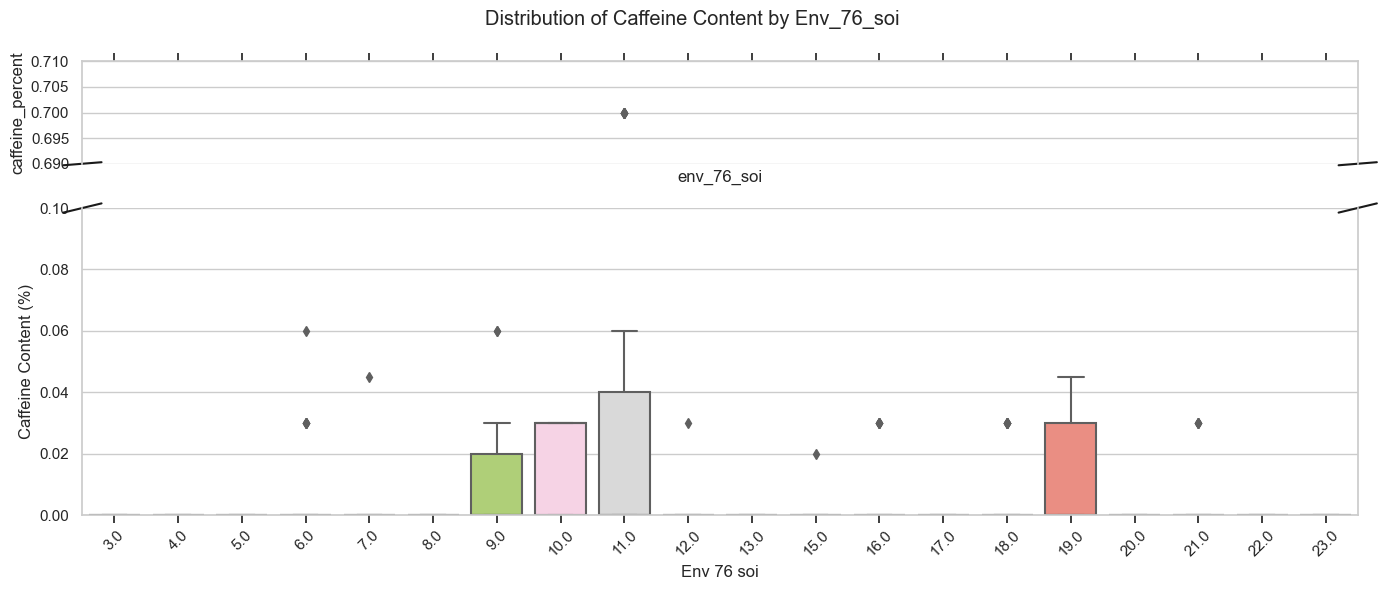

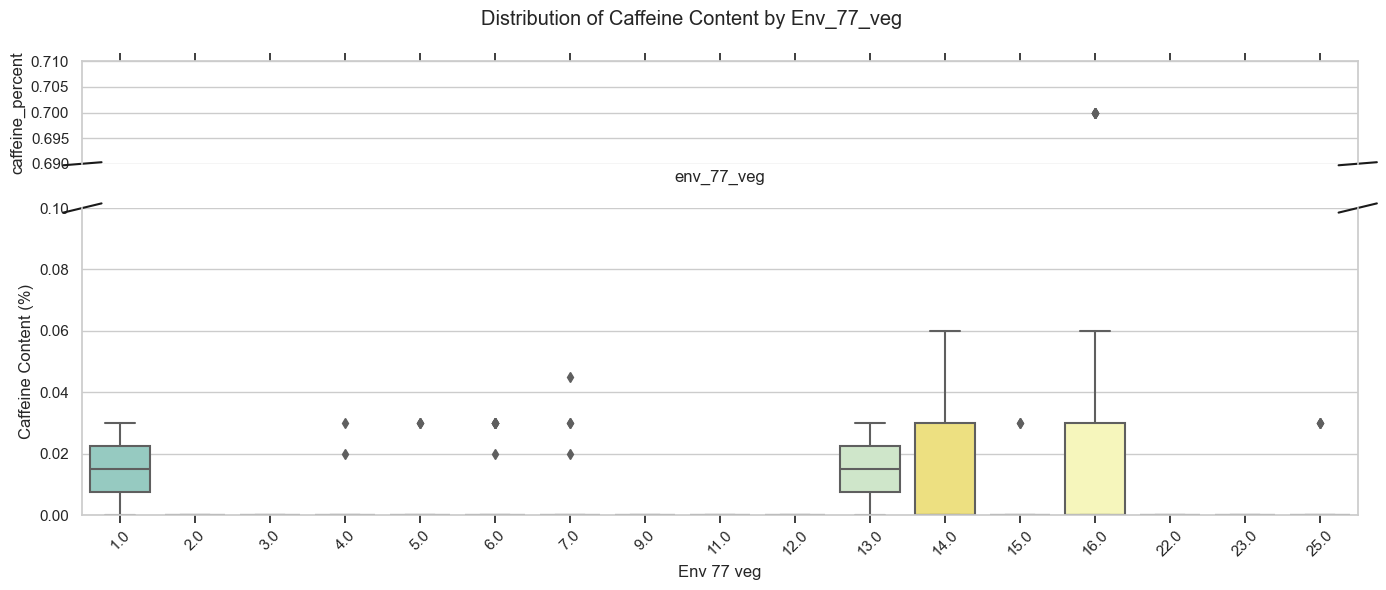

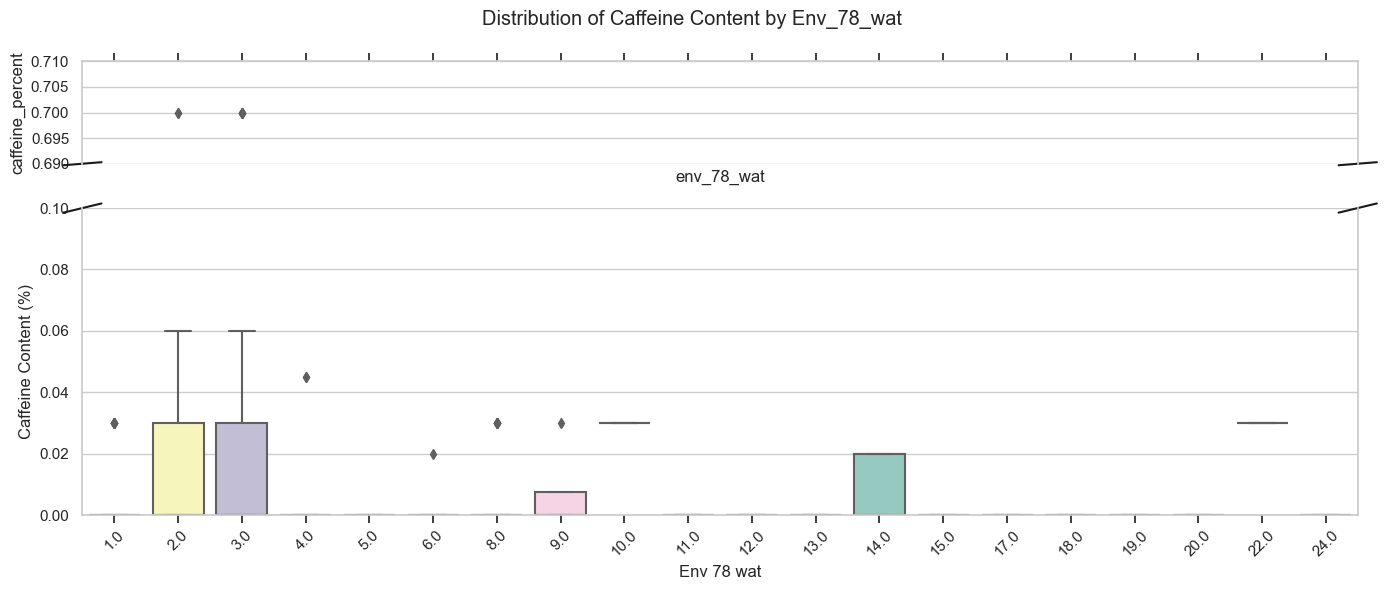

In [19]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# List of categorical columns you want to visualize
categorical_columns = ['env_75_geo', 'env_76_soi', 'env_77_veg', 'env_78_wat']

# Loop through each column and create a box plot with a broken y-axis
for column in categorical_columns:
    fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(14, 6), gridspec_kw={'height_ratios': [1, 3]})
    
    # Top plot (focused on 0.69 to 0.71 range)
    sns.boxplot(x=column, y='caffeine_percent', data=df, palette='Set3', ax=ax1)
    ax1.set_ylim(0.69, 0.71)  # Display a small range above the break
    ax1.set_yticks(np.arange(0.69, 0.71, 0.005))  # Adjust interval for the narrow section

    # Bottom plot (below 0.1)
    sns.boxplot(x=column, y='caffeine_percent', data=df, palette='Set3', ax=ax2)
    ax2.set_ylim(0, 0.1)  # Emphasize the main range
    ax2.set_yticks(np.arange(0, 0.11, 0.02))  # Set the interval for the bottom part

    # Formatting for better visualization
    ax1.spines['bottom'].set_visible(False)
    ax2.spines['top'].set_visible(False)
    ax1.xaxis.tick_top()
    ax1.tick_params(labeltop=False)  # Don't put tick labels at the top
    ax2.xaxis.tick_bottom()

    # Add diagonal lines to indicate the break in the y-axis
    d = .015  # How big to make the diagonal lines in axes coordinates
    kwargs = dict(transform=ax1.transAxes, color='k', clip_on=False)
    ax1.plot((-d, +d), (-d, +d), **kwargs)  # Top-left diagonal
    ax1.plot((1 - d, 1 + d), (-d, +d), **kwargs)  # Top-right diagonal

    kwargs.update(transform=ax2.transAxes)  # Switch to the bottom axes
    ax2.plot((-d, +d), (1 - d, 1 + d), **kwargs)  # Bottom-left diagonal
    ax2.plot((1 - d, 1 + d), (1 - d, 1 + d), **kwargs)  # Bottom-right diagonal

    # Set labels and titles
    ax2.set_xlabel(column.replace('_', ' ').capitalize())
    ax2.set_ylabel('Caffeine Content (%)')
    plt.suptitle(f'Distribution of Caffeine Content by {column.capitalize()}')
    plt.xticks(rotation=45)  # Rotate x-axis labels if needed
    
    plt.tight_layout()
    plt.show()



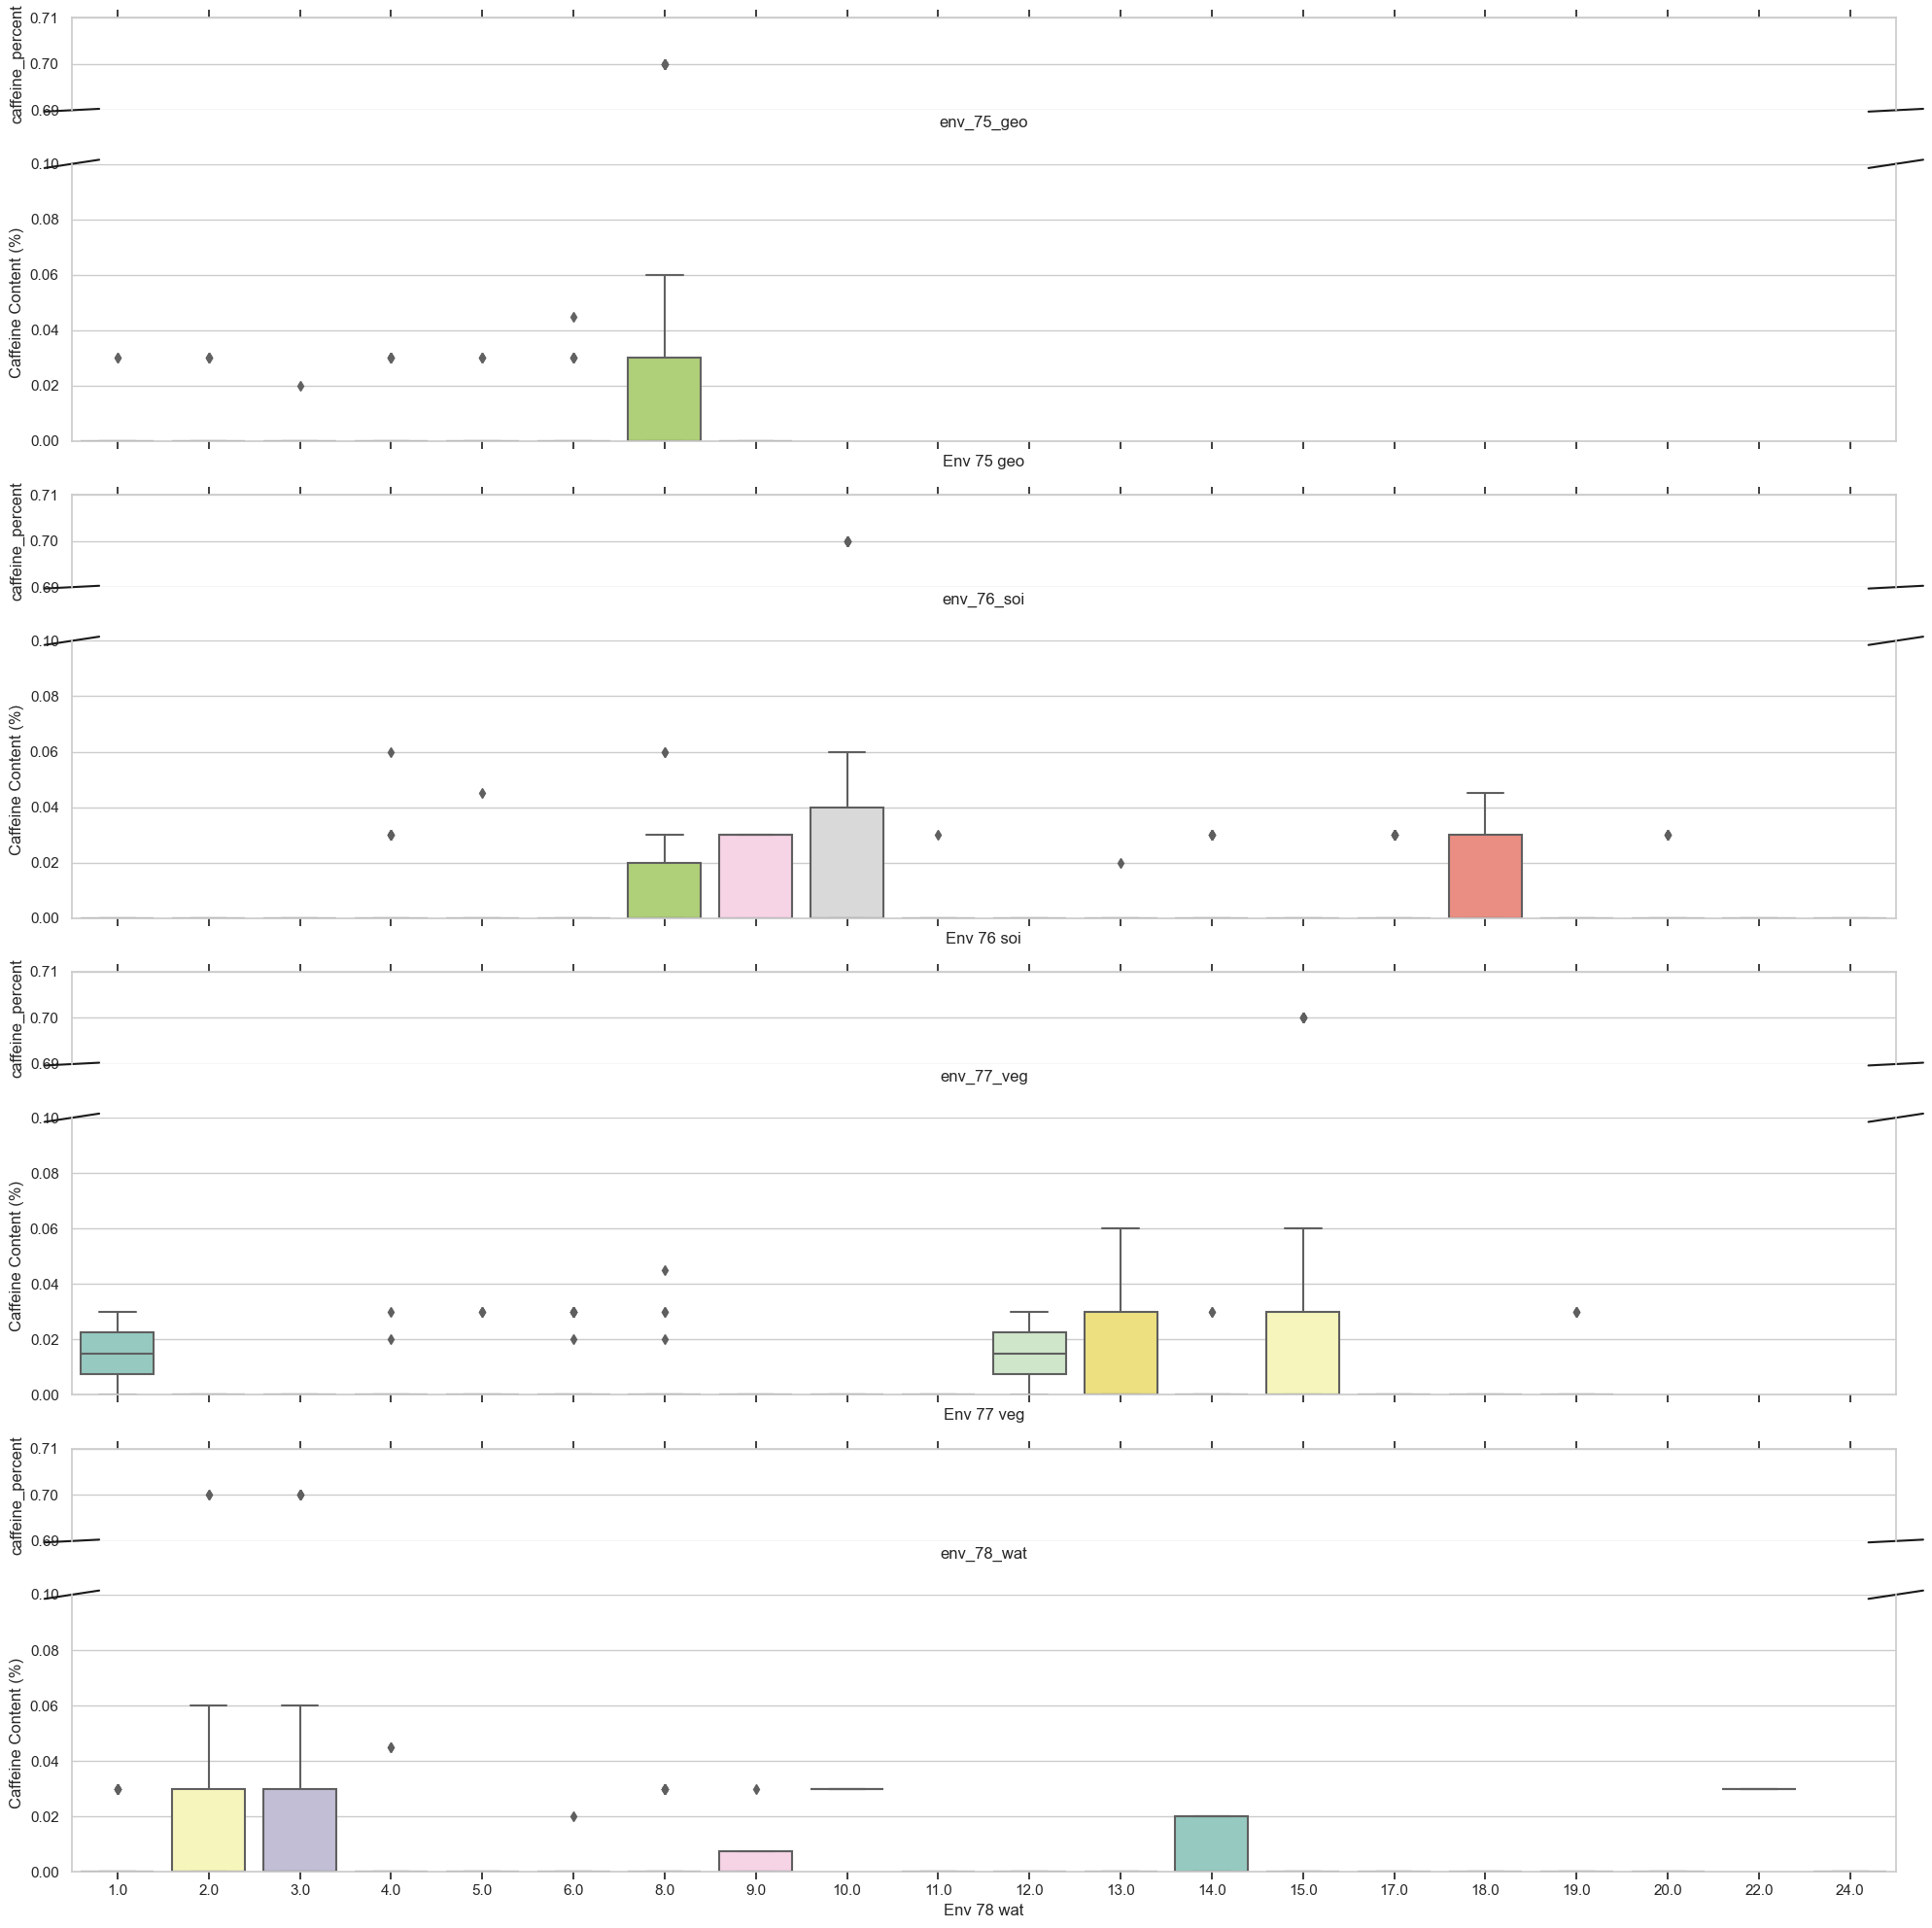

In [20]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# List of categorical columns you want to visualize
categorical_columns = ['env_75_geo', 'env_76_soi', 'env_77_veg', 'env_78_wat']

# Create a figure with subplots for each categorical variable (2 subplots per variable)
fig, axes = plt.subplots(len(categorical_columns) * 2, 1, sharex=True, figsize=(20, 20),
                         gridspec_kw={'height_ratios': [1, 3] * len(categorical_columns)})

# Loop through each column and create a box plot with a broken y-axis
for i, column in enumerate(categorical_columns):
    ax1 = axes[i * 2]  # Top plot
    ax2 = axes[i * 2 + 1]  # Bottom plot
    
    # Top plot (focused on 0.69 to 0.71 range)
    sns.boxplot(x=column, y='caffeine_percent', data=df, palette='Set3', ax=ax1)
    ax1.set_ylim(0.69, 0.71)  # Display a small range above the break
    ax1.set_yticks(np.arange(0.69, 0.71, 0.01))  # Adjust interval for the narrow section

    # Bottom plot (below 0.1)
    sns.boxplot(x=column, y='caffeine_percent', data=df, palette='Set3', ax=ax2)
    ax2.set_ylim(0, 0.1)  # Emphasize the main range
    ax2.set_yticks(np.arange(0, 0.11, 0.02))  # Set interval for the bottom part

    # Formatting for better visualization
    ax1.spines['bottom'].set_visible(False)
    ax2.spines['top'].set_visible(False)
    ax1.xaxis.tick_top()
    ax1.tick_params(labeltop=False)  # Don't put tick labels at the top
    ax2.xaxis.tick_bottom()

    # Add diagonal lines to indicate the break in the y-axis
    d = .015  # How big to make the diagonal lines in axes coordinates
    kwargs = dict(transform=ax1.transAxes, color='k', clip_on=False)
    ax1.plot((-d, +d), (-d, +d), **kwargs)  # Top-left diagonal
    ax1.plot((1 - d, 1 + d), (-d, +d), **kwargs)  # Top-right diagonal

    kwargs.update(transform=ax2.transAxes)  # Switch to the bottom axes
    ax2.plot((-d, +d), (1 - d, 1 + d), **kwargs)  # Bottom-left diagonal
    ax2.plot((1 - d, 1 + d), (1 - d, 1 + d), **kwargs)  # Bottom-right diagonal

    # Set labels and titles
    ax2.set_xlabel(column.replace('_', ' ').capitalize())
    ax2.set_ylabel('Caffeine Content (%)')
    #ax1.set_title(f'Distribution of Caffeine Content by {column.capitalize()}')

# Adjust layout to avoid overlap
plt.tight_layout()
plt.show()


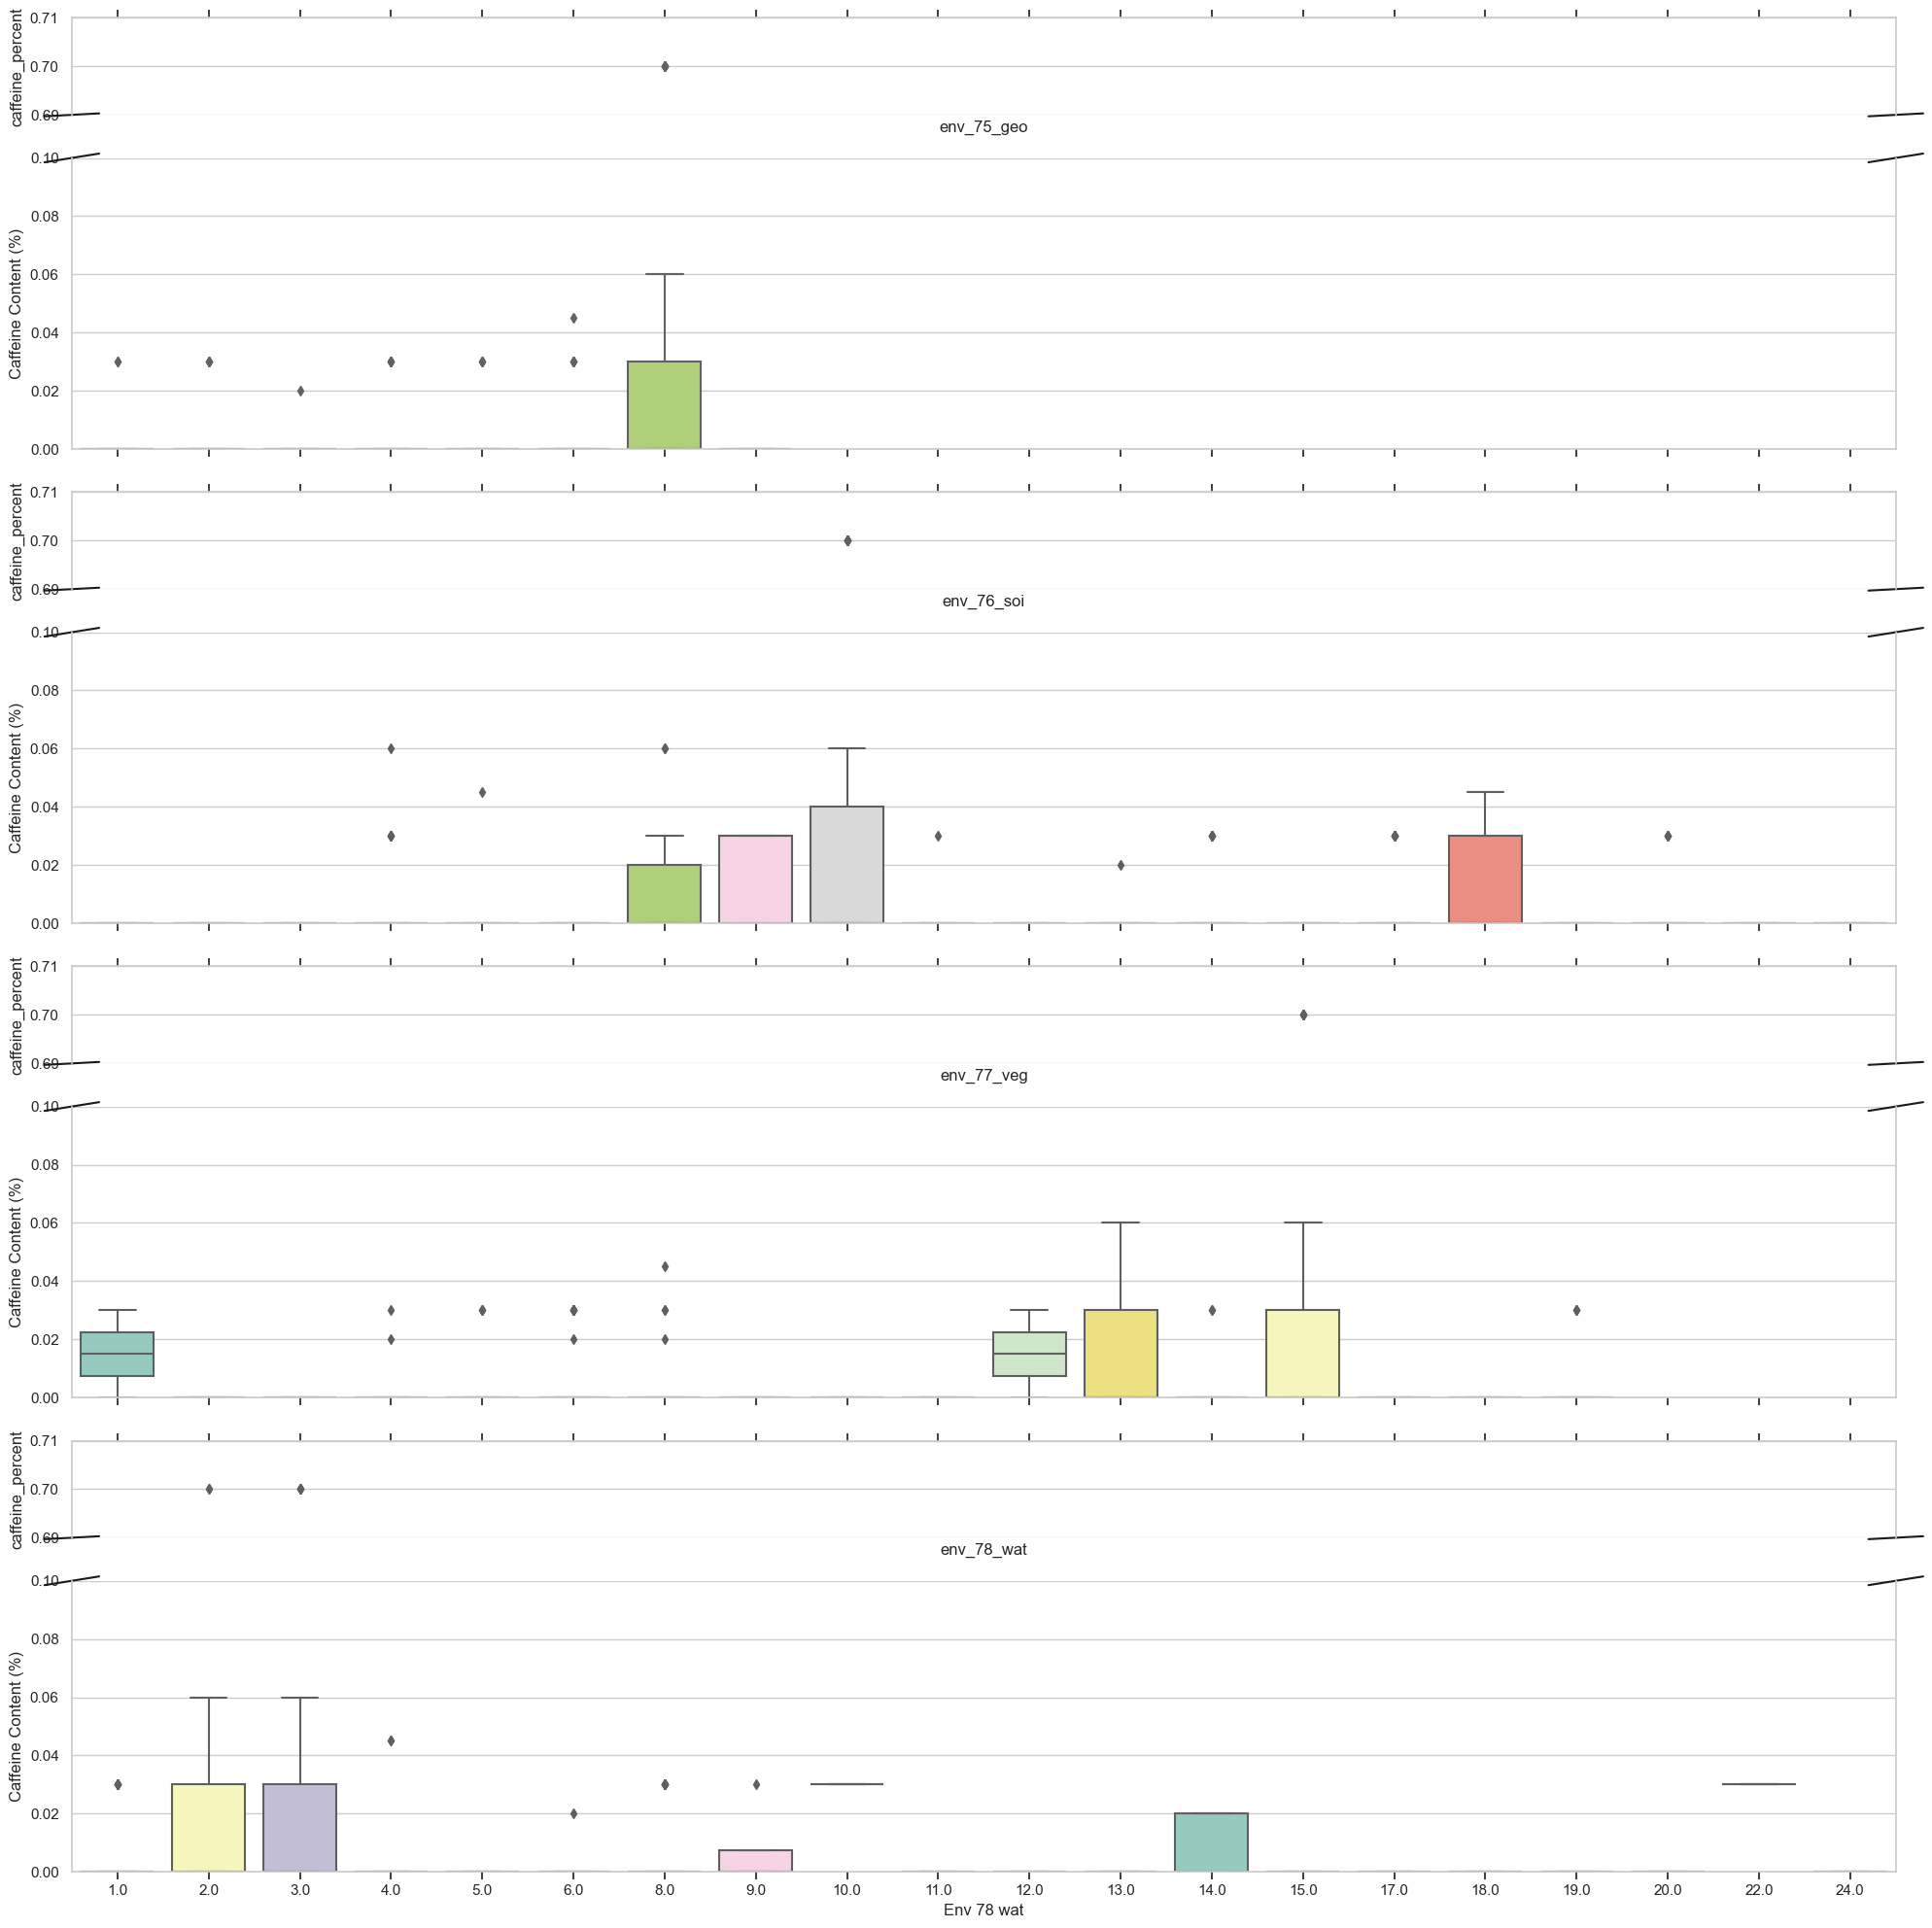

In [21]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# List of categorical columns you want to visualize
categorical_columns = ['env_75_geo', 'env_76_soi', 'env_77_veg', 'env_78_wat']

# Create a figure with subplots for each categorical variable (2 subplots per variable)
fig, axes = plt.subplots(len(categorical_columns) * 2, 1, sharex=True, figsize=(20, 20),
                         gridspec_kw={'height_ratios': [1, 3] * len(categorical_columns)})

# Loop through each column and create a box plot with a broken y-axis
for i, column in enumerate(categorical_columns):
    ax1 = axes[i * 2]  # Top plot
    ax2 = axes[i * 2 + 1]  # Bottom plot
    
    # Top plot (focused on 0.69 to 0.71 range)
    sns.boxplot(x=column, y='caffeine_percent', data=df, palette='Set3', ax=ax1)
    ax1.set_ylim(0.69, 0.71)  # Display a small range above the break
    ax1.set_yticks(np.arange(0.69, 0.71, 0.01))  # Adjust interval for the narrow section

    # Bottom plot (below 0.1)
    sns.boxplot(x=column, y='caffeine_percent', data=df, palette='Set3', ax=ax2)
    ax2.set_ylim(0, 0.1)  # Emphasize the main range
    ax2.set_yticks(np.arange(0, 0.11, 0.02))  # Set interval for the bottom part

    # Formatting for better visualization
    ax1.spines['bottom'].set_visible(False)
    ax2.spines['top'].set_visible(False)
    ax1.xaxis.tick_top()
    ax1.tick_params(labeltop=False)  # Don't put tick labels at the top
    ax2.xaxis.tick_bottom()

    # Add diagonal lines to indicate the break in the y-axis
    d = .015  # How big to make the diagonal lines in axes coordinates
    kwargs = dict(transform=ax1.transAxes, color='k', clip_on=False)
    ax1.plot((-d, +d), (-d, +d), **kwargs)  # Top-left diagonal
    ax1.plot((1 - d, 1 + d), (-d, +d), **kwargs)  # Top-right diagonal

    kwargs.update(transform=ax2.transAxes)  # Switch to the bottom axes
    ax2.plot((-d, +d), (1 - d, 1 + d), **kwargs)  # Bottom-left diagonal
    ax2.plot((1 - d, 1 + d), (1 - d, 1 + d), **kwargs)  # Bottom-right diagonal

    # Set labels and titles
    if i == len(categorical_columns) - 1:
        ax2.set_xlabel(column.replace('_', ' ').capitalize())
    else:
        ax2.set_xlabel('')

    ax2.set_ylabel('Caffeine Content (%)')

# Adjust layout to avoid overlap
plt.tight_layout()
plt.show()


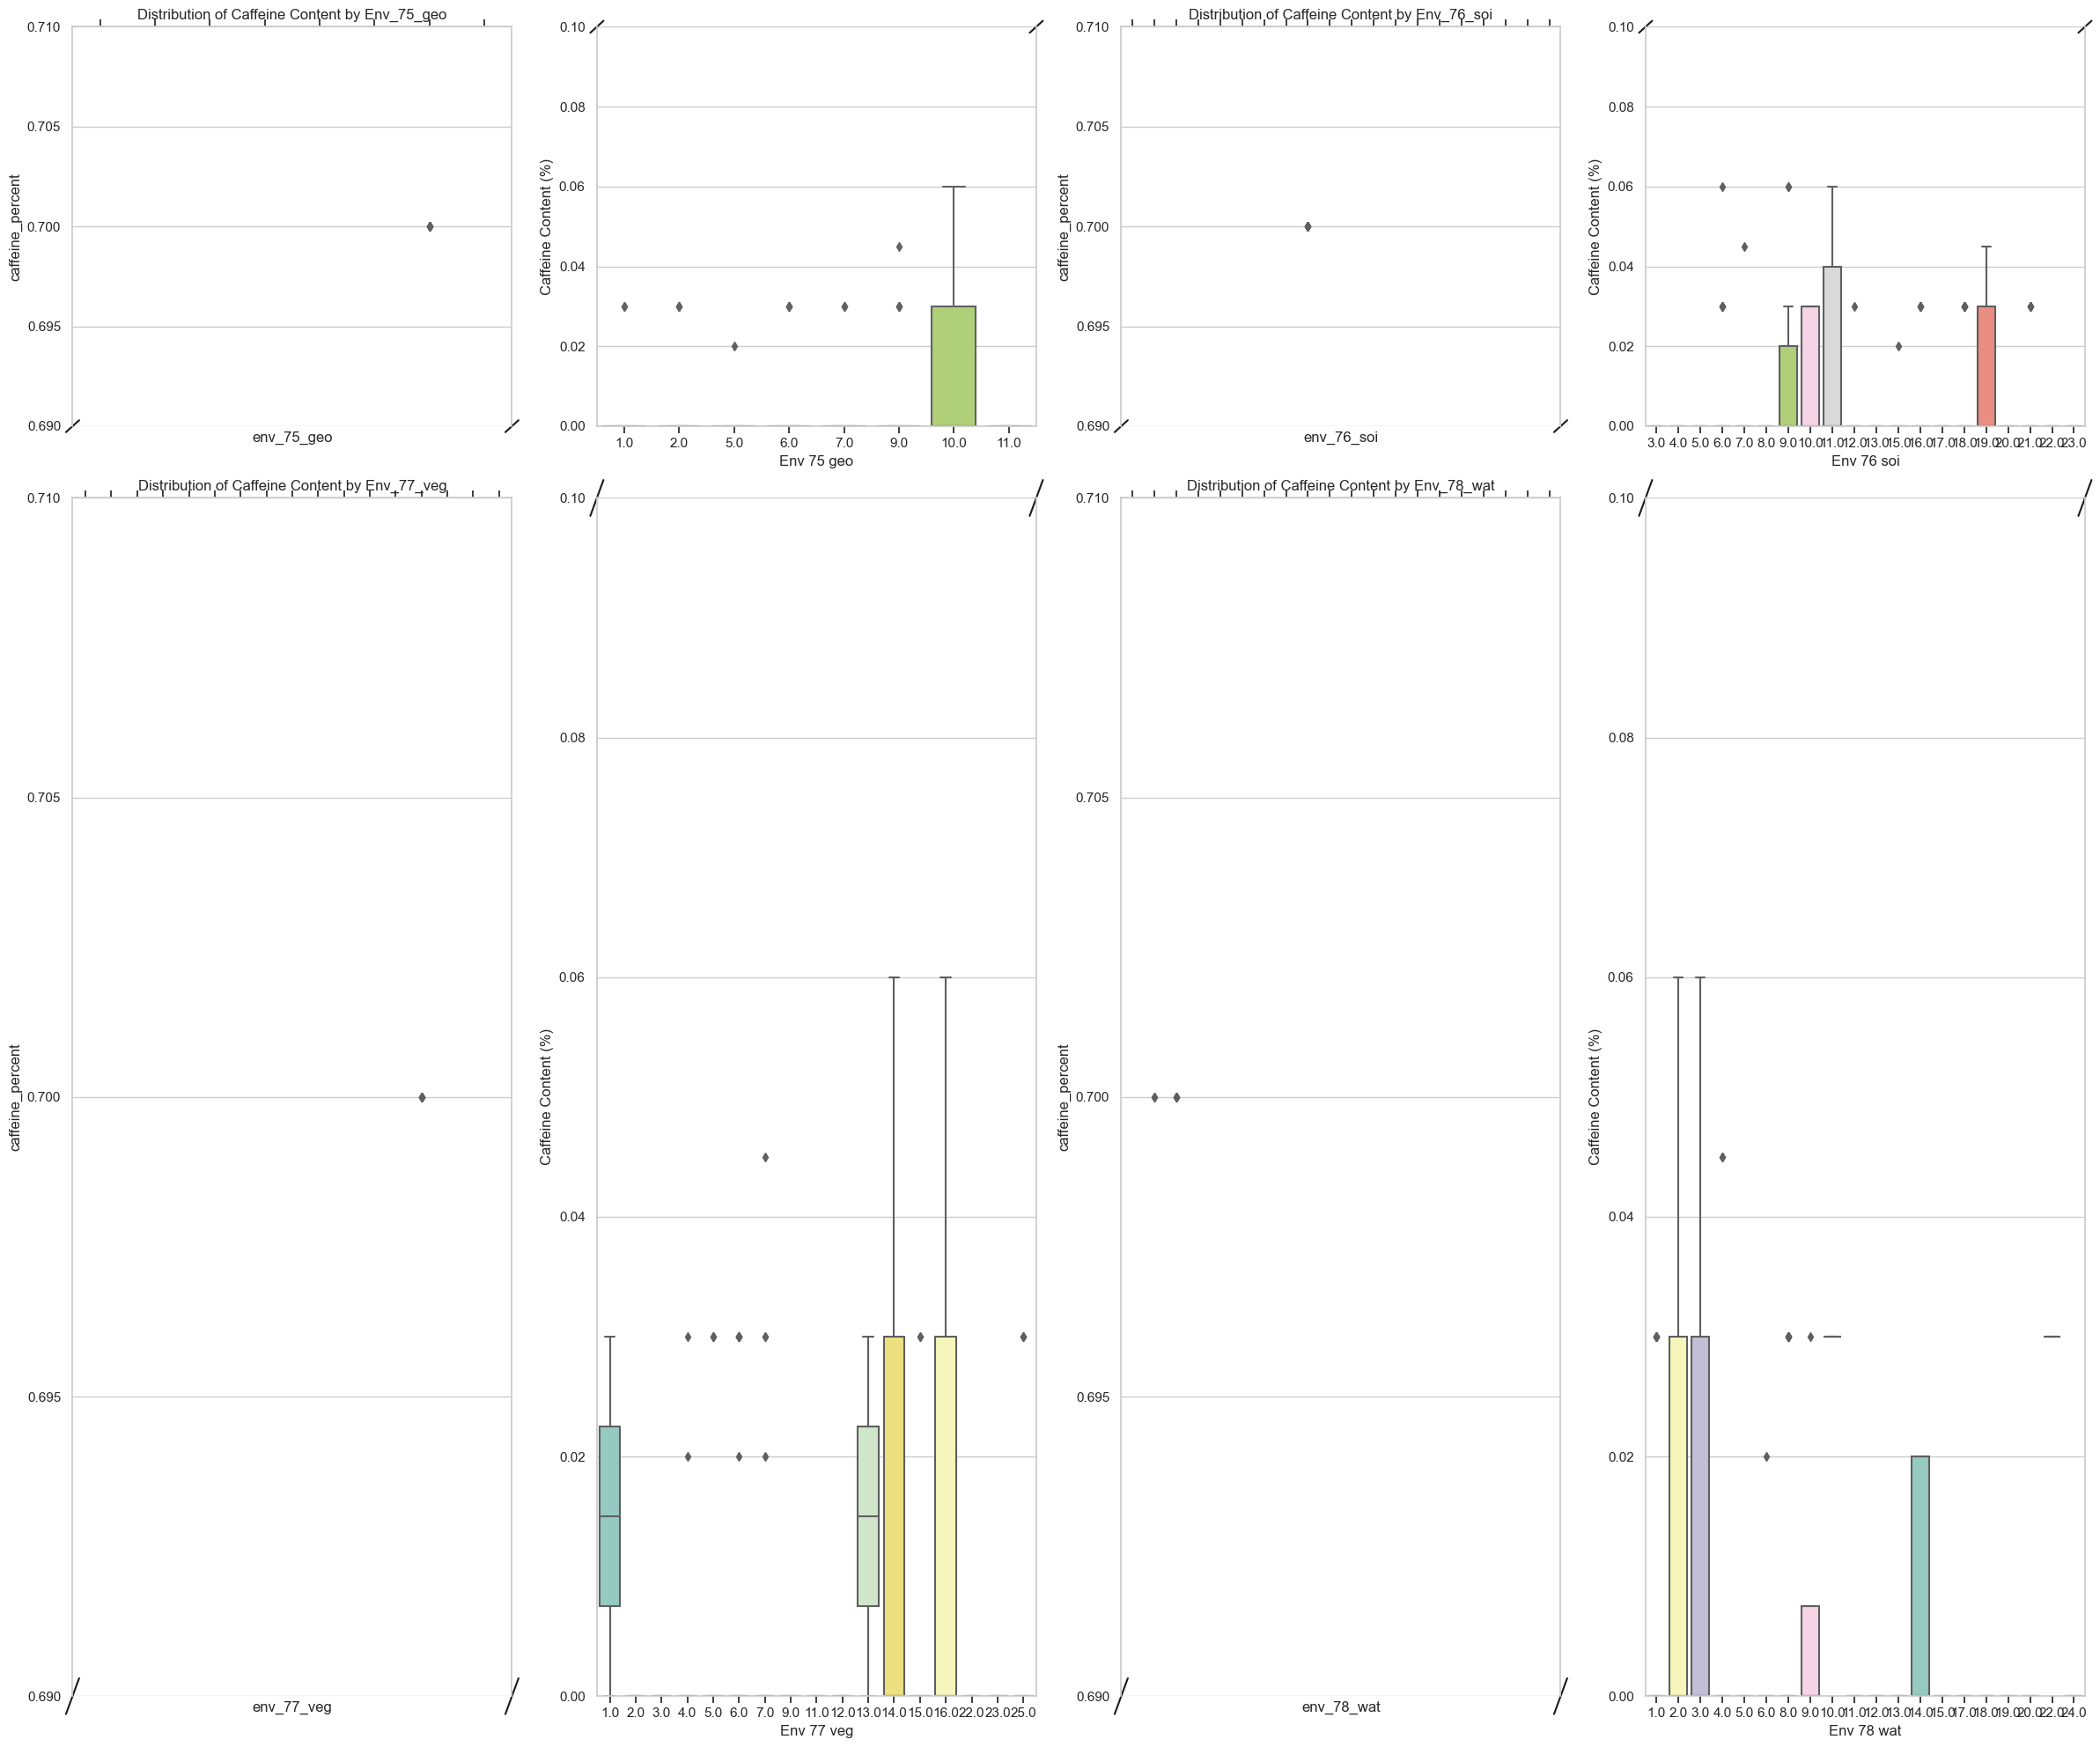

In [22]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# List of categorical columns you want to visualize
categorical_columns = ['env_75_geo', 'env_76_soi', 'env_77_veg', 'env_78_wat']

# Create a figure with a 4x2 grid of subplots (2 rows per variable)
fig, axes = plt.subplots(2, 4, figsize=(24, 20), gridspec_kw={'height_ratios': [1, 3]})

# Flatten the axes for easier iteration
axes = axes.flatten()

# Loop through each column and create a box plot with a broken y-axis
for i, column in enumerate(categorical_columns):
    top_ax = axes[i * 2]  # Top plot
    bottom_ax = axes[i * 2 + 1]  # Bottom plot
    
    # Top plot (focused on 0.69 to 0.71 range)
    sns.boxplot(x=column, y='caffeine_percent', data=df, palette='Set3', ax=top_ax)
    top_ax.set_ylim(0.69, 0.71)  # Display a small range above the break
    top_ax.set_yticks(np.arange(0.69, 0.71, 0.005))  # Adjust interval for the narrow section
    top_ax.spines['bottom'].set_visible(False)
    top_ax.xaxis.tick_top()
    top_ax.tick_params(labeltop=False)

    # Bottom plot (below 0.1)
    sns.boxplot(x=column, y='caffeine_percent', data=df, palette='Set3', ax=bottom_ax)
    bottom_ax.set_ylim(0, 0.1)  # Emphasize the main range
    bottom_ax.set_yticks(np.arange(0, 0.11, 0.02))  # Set interval for the bottom part
    bottom_ax.spines['top'].set_visible(False)
    bottom_ax.xaxis.tick_bottom()

    # Add diagonal lines to indicate the break in the y-axis for top and bottom plots
    d = .015  # How big to make the diagonal lines in axes coordinates
    kwargs = dict(transform=top_ax.transAxes, color='k', clip_on=False)
    top_ax.plot((-d, +d), (-d, +d), **kwargs)  # Top-left diagonal
    top_ax.plot((1 - d, 1 + d), (-d, +d), **kwargs)  # Top-right diagonal

    kwargs.update(transform=bottom_ax.transAxes)  # Switch to the bottom axes
    bottom_ax.plot((-d, +d), (1 - d, 1 + d), **kwargs)  # Bottom-left diagonal
    bottom_ax.plot((1 - d, 1 + d), (1 - d, 1 + d), **kwargs)  # Bottom-right diagonal

    # Set labels and titles
    bottom_ax.set_xlabel(column.replace('_', ' ').capitalize())
    bottom_ax.set_ylabel('Caffeine Content (%)')
    top_ax.set_title(f'Distribution of Caffeine Content by {column.capitalize()}')

# Adjust layout to avoid overlap
plt.tight_layout()
plt.show()


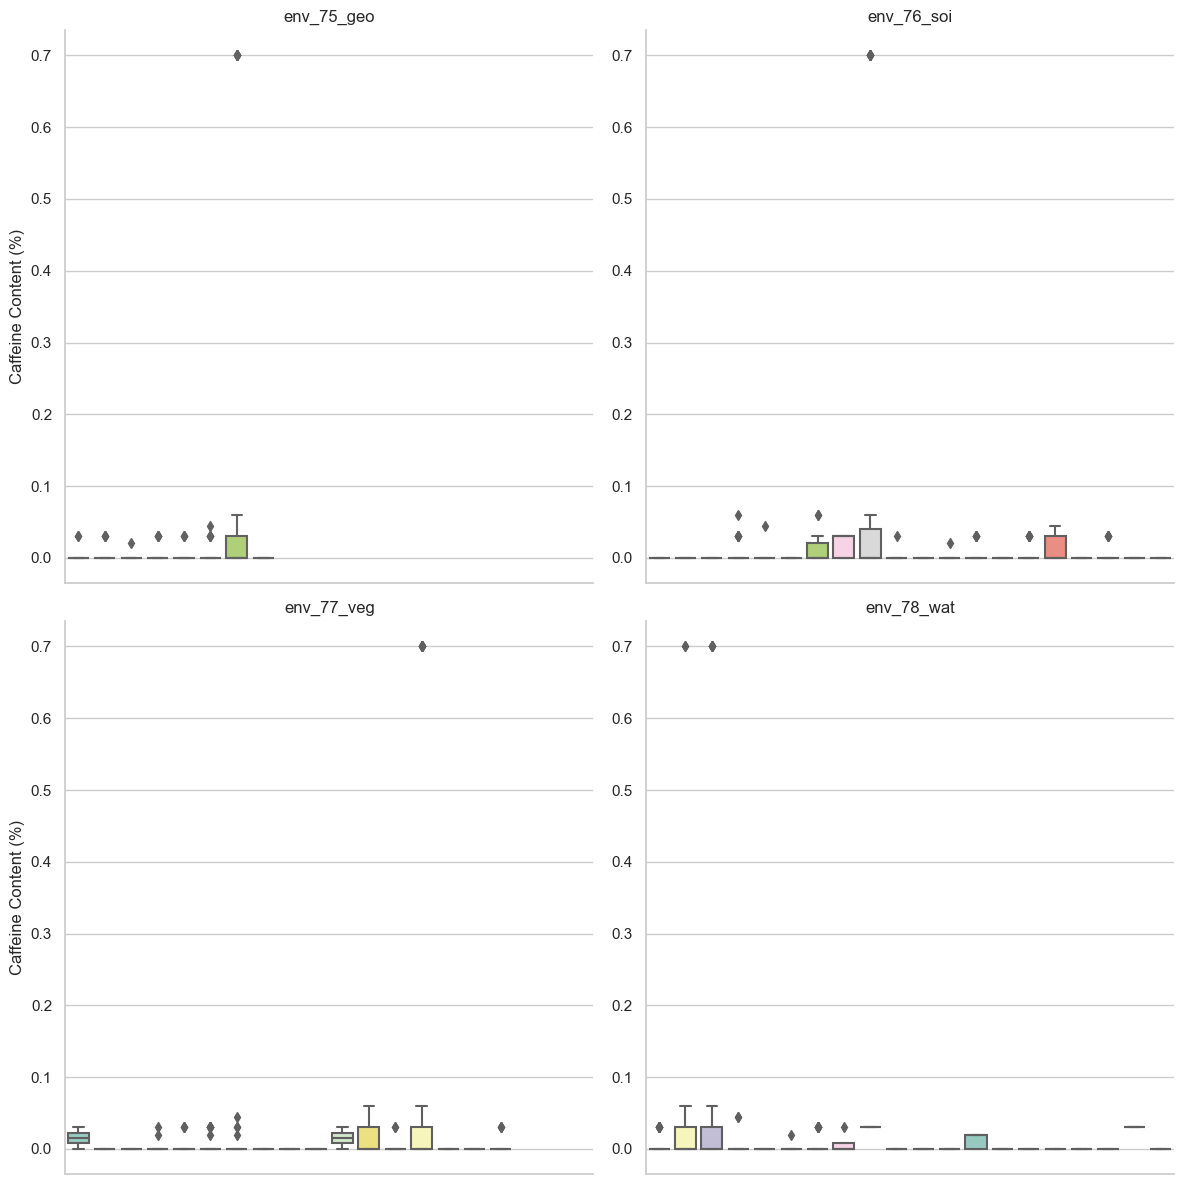

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Sample DataFrame (replace with your actual data)
# df = pd.read_csv('your_data.csv')

# Melt the DataFrame to have a common 'Category' column for the categorical variables
melted_df = pd.melt(df, id_vars='caffeine_percent', value_vars=['env_75_geo', 'env_76_soi',  'env_77_veg',  'env_78_wat' ],
                    var_name='Category', value_name='Category Value')

# Create a FacetGrid
g = sns.FacetGrid(melted_df, col='Category', col_wrap=2, height=6, sharey=False)
g.map_dataframe(sns.boxplot, x='Category Value', y='caffeine_percent', palette='Set3')

# Customize the plots
g.set_titles("{col_name}")
g.set_axis_labels("", "Caffeine Content (%)")
for ax in g.axes.flat:
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45)

plt.tight_layout()
plt.show()


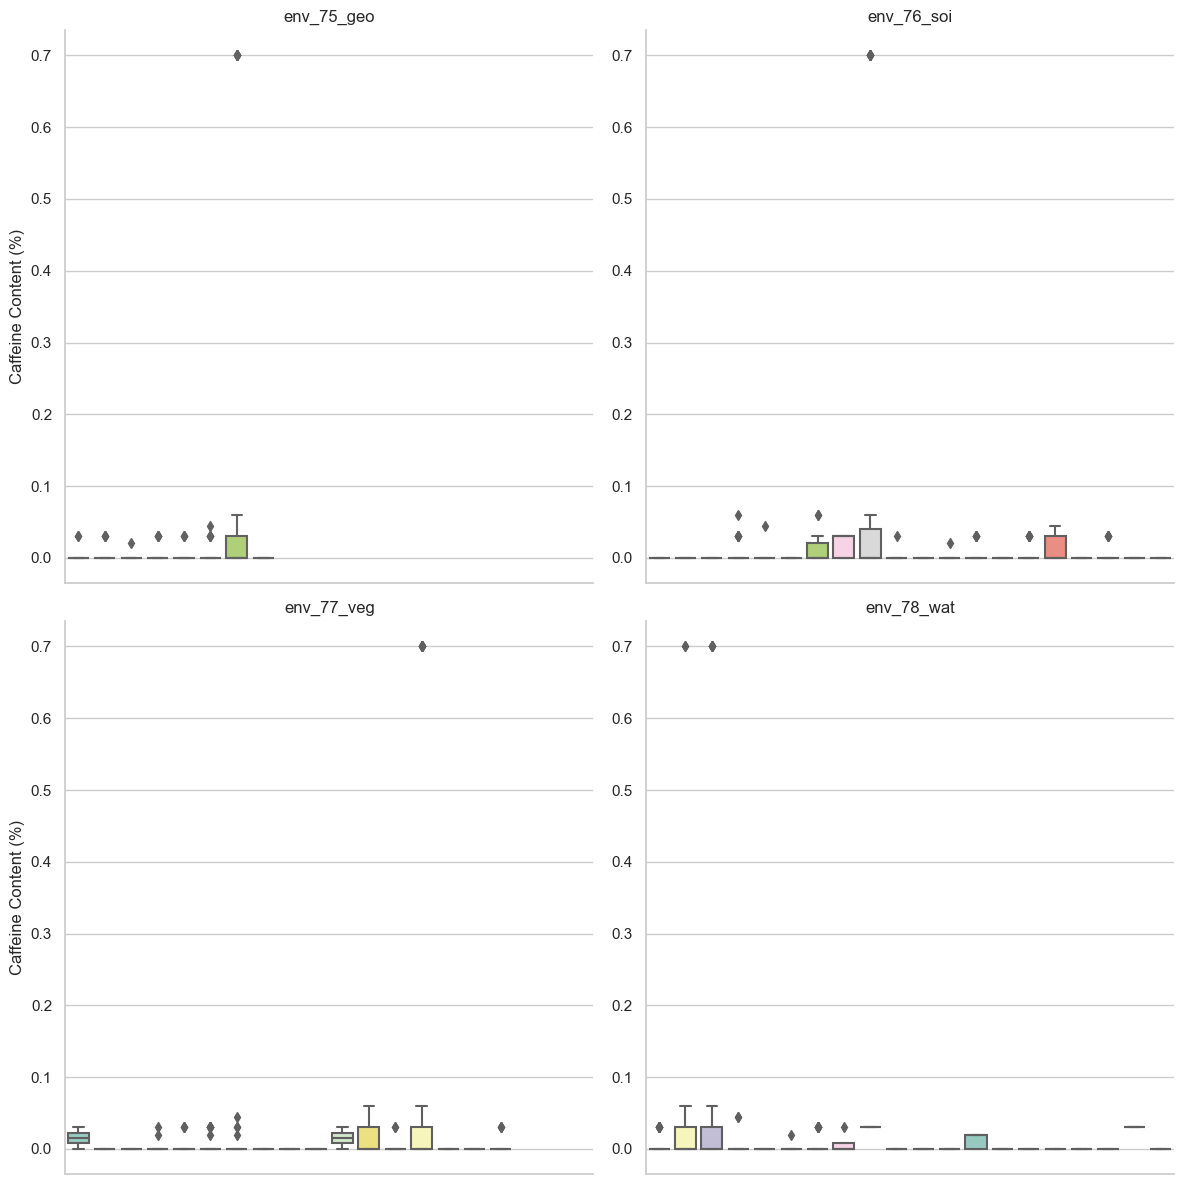

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Sample DataFrame (replace with your actual data)
# df = pd.read_csv('your_data.csv')

# Melt the DataFrame to have a common 'Category' column for the categorical variables
melted_df = pd.melt(df, id_vars='caffeine_percent', value_vars=['env_75_geo', 'env_76_soi',  'env_77_veg',  'env_78_wat'],
                    var_name='Category', value_name='Category Value')

# Create a FacetGrid
g = sns.FacetGrid(melted_df, col='Category', col_wrap=2, height=6, sharey=False)
g.map_dataframe(sns.boxplot, x='Category Value', y='caffeine_percent', palette='Set3')

# Customize the plots
g.set_titles("{col_name}")
g.set_axis_labels("", "Caffeine Content (%)")
for ax in g.axes.flat:
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')  # Rotate and align labels

plt.tight_layout()
plt.show()


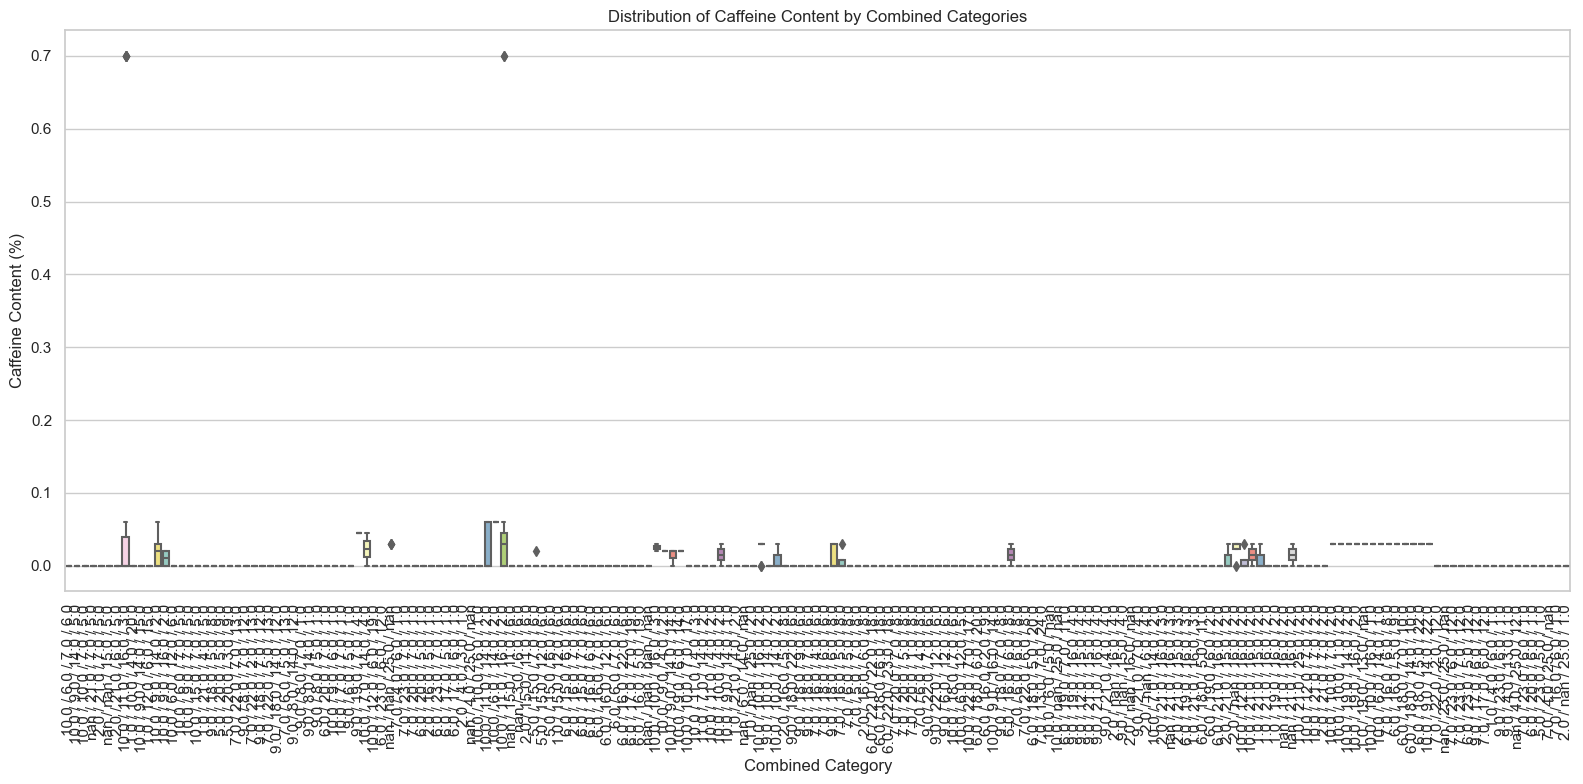

In [25]:
'', '',  '',  ''

import seaborn as sns
import matplotlib.pyplot as plt

# Combine all categories into a new column for grouping
df['combined_category'] = (df['env_75_geo'].astype(str) + " / " +
                           df['env_76_soi'].astype(str) + " / " +
                           df['env_77_veg'].astype(str) + " / " +
                           df['env_78_wat'].astype(str))

# Plot with a grouped boxplot
plt.figure(figsize=(16, 8))
sns.boxplot(x='combined_category', y='caffeine_percent', data=df, palette='Set3')
plt.title('Distribution of Caffeine Content by Combined Categories')
plt.xlabel('Combined Category')
plt.ylabel('Caffeine Content (%)')
plt.xticks(rotation=90, ha='center')  # Rotate and center align labels
plt.tight_layout()
plt.show()


In [26]:
pd.set_option('display.max_rows', None)


Trying 3 steps of Feature selection

1. Lasso
2. RFC
3. SHAP

Step 1: LASSO for Feature Selection

This step fits a LASSO regression model (with cross-validation to tune the regularization parameter) and then selects only features with non-zero coefficients.

In [29]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

coffea_caff = pd.read_csv(r"..\data\cleaned_data_w_class.csv")
coffee_data = coffea_caff.copy()

# Adjust the feature selection (drop target columns) as needed.
features = coffee_data.drop(columns=['caffeine_percent', 'caffeine_class', 'Species_name'], errors='ignore')
target = coffee_data['caffeine_percent']
# Suppose numerical_features is a list of your numerical feature names,
# and onehot_features is a list of your one-hot encoded column names.
numerical_features = list(coffee_data.filter(like='clim_').columns) + [ 'env_71_alt', 'env_72_slo', 'env_73_asp', 'env_74_solrad', 'env_79_forcov' ]

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features)
        # One-hot features can be passed through unchanged:
        # ('cat', 'passthrough', onehot_features)
    ],
    remainder='passthrough'
)


# Split the data (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state=42)

X_train_scaled = preprocessor.fit_transform(X_train)
X_test_scaled = preprocessor.transform(X_test)

In [30]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LassoCV


# Fit Lasso with cross-validation to automatically tune alpha
lasso_cv = LassoCV(cv=5, random_state=42, max_iter=10000)
lasso_cv.fit(X_train_scaled, y_train)

# Get the coefficients and select features with non-zero coefficients
coef = pd.Series(lasso_cv.coef_, index=X_train.columns)
selected_features = coef[coef != 0].index.tolist()
print("Features selected by Lasso (non-zero coefficients):")
print(selected_features)


c:\Users\adm1\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:683: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 0.0006228265824361756, tolerance: 0.0002882187499999999
  model = cd_fast.enet_coordinate_descent_gram(
c:\Users\adm1\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:683: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 0.00034301919336199305, tolerance: 0.0002882187499999999
  model = cd_fast.enet_coordinate_descent_gram(
c:\Users\adm1\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:683: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 0.0014139117865963335, tolerance: 0.0002882187499999999
  model = cd_fast.enet_coordin

Features selected by Lasso (non-zero coefficients):
['clim_34_prec10_oct', 'clim_39_isotherm', 'clim_64_pet9_sep', 'env_72_slo', 'env_73_asp', 'env_74_solrad', 'env_79_forcov', 'env_75_geo_10', 'env_76_soi_11', 'env_77_veg_16']


c:\Users\adm1\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:683: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 0.013962188181574575, tolerance: 0.0002414941319444444
  model = cd_fast.enet_coordinate_descent_gram(
c:\Users\adm1\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:683: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 0.013863945576478187, tolerance: 0.0002414941319444444
  model = cd_fast.enet_coordinate_descent_gram(
c:\Users\adm1\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:683: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 0.012650798443729183, tolerance: 0.0002414941319444444
  model = cd_fast.enet_coordinate_

Checking the stability of feature selection via repeated cross‐validation (using bootstrapping) and record which features are consistently selected by LassoCV after scaling. 

The code runs multiple iterations (bootstrap resampling with different random seeds) and counts how frequently each feature is selected (i.e. gets a nonzero coefficient).

In [32]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LassoCV
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from collections import Counter
import warnings
from sklearn.exceptions import ConvergenceWarning

warnings.filterwarnings("ignore", category=ConvergenceWarning)

data = coffee_data.copy()

feature_columns = [col for col in data.columns if col not in ['caffeine_percent', 'caffeine_class', 'Species_name']]
X = data[feature_columns]
y = data['caffeine_percent']

# If you haven't scaled yet, do so only on numerical features;
# Here we assume X is all numerical or already processed appropriately.
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

# Optionally, you could split into train/test, but for stability selection,
# you can work with the full data or with the training subset.
# Here, we work with the full scaled data.
# X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Parameters for stability selection
n_iterations = 100  # Number of bootstrap samples
selected_features_list = []

for i in range(n_iterations):
    # Create a bootstrap sample (sample with replacement)
    bootstrap_indices = np.random.choice(np.arange(X_scaled.shape[0]), size=X_scaled.shape[0], replace=True)
    X_bootstrap = X_scaled.iloc[bootstrap_indices]
    y_bootstrap = y.iloc[bootstrap_indices]
    
    # Fit LassoCV (increase max_iter to help convergence)
    lasso_cv = LassoCV(cv=5, max_iter=10000, random_state=i)
    lasso_cv.fit(X_bootstrap, y_bootstrap)
    
    # Record features with non-zero coefficients
    selected = X_scaled.columns[(lasso_cv.coef_ != 0)]
    selected_features_list.extend(selected)

# Count how often each feature was selected across iterations
feature_counts = Counter(selected_features_list)
stability_df = pd.DataFrame.from_dict(feature_counts, orient='index', columns=['selection_frequency'])
stability_df['selection_rate'] = stability_df['selection_frequency'] / n_iterations
stability_df = stability_df.sort_values(by='selection_rate', ascending=False)

print("Stability Selection Results:")
print(stability_df)


KeyboardInterrupt: 

### Random Forest and Permutation Importance
Here we train a Random Forest regressor on the selected features and use both the built-in feature importances and permutation importance to rank predictors.

In [33]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance
selected_features = stability_df[stability_df['selection_frequency'] > 80]

# Train a Random Forest Regressor on the features selected by Lasso
rf = RandomForestRegressor(n_estimators=200, random_state=42)
rf.fit(X_train[selected_features], y_train)

# Get the built-in feature importances from the Random Forest
rf_importances = pd.Series(rf.feature_importances_, index=selected_features).sort_values(ascending=False)
print("Random Forest Feature Importances:")
print(rf_importances)

# Calculate permutation importance on the test set
perm_importance = permutation_importance(rf, X_test[selected_features], y_test, n_repeats=30, random_state=42)
perm_importances = pd.Series(perm_importance.importances_mean, index=selected_features).sort_values(ascending=False)
print("Permutation Importances:")
print(perm_importances)


NameError: name 'stability_df' is not defined

### SHAP Values for Detailed Interpretability
Using the SHAP library, we compute SHAP values for the Random Forest model to see how each feature contributes to predictions.

In [44]:
import shap
import matplotlib.pyplot as plt

# Create a TreeExplainer for the Random Forest
explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_test[selected_features])

# Summary plot of SHAP values
shap.summary_plot(shap_values, X_test[selected_features])
    

c:\Users\adm1\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


NameError: name 'rf' is not defined